# Absorption Coefficient numeric Calculation

In [1]:
#  imports
from IPython.display import Markdown, display
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt
from time import time
try:
    from scipy.integrate import solve_ivp
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
from scipy.optimize import curve_fit

## Constants

In [2]:
# param
ODE_SOLVE_METHOD = 'RK45'  # 'Radau', 'BDF', 'LSODA', 'RK45', etc.

# --- Physical constants ---
h = 6.62607015e-34        # Planck constant, J·s
hbar = h / (2 * np.pi)    # Reduced Planck constant, J·s
k_B = 1.380649e-23        # Boltzmann constant, J/K
c = 299792458.0           # Speed of light, m/s
amu = 1.66053906660e-27   # Atomic mass unit, kg

# --- Transition parameters ---
f_S12_to_P12 = 377.107463380e12        # Hz
f_S12F1_to_S12 = 4.271676631815181e9  # Hz
f_S12F1_to_S12F2 = 6.834682610904290e9  # Hz
f_P12F1_to_P12 = 509.06e6           # Hz
f_p12F1_to_P12F2 = 814.5e6          # Hz

f_S12_to_P32 = 384.2304844685e12
# f_S12F1_to_S12 = 4.271676631815181e9
f_P32F0_to_P32 = 302.0738e6
f_P32F0_to_P32F1 = 72.2180e6
f_P32F1_to_P32F2 = 156.9470e6
f_P32F2_to_P32F3 = 266.6500e6

#----------------------ASSUMPTION--------------------
# extra multiplicative term from matching my derivation with einstein B convention, should be 3, but nonexistent (1) in the reference
S_CONVENTION_CORRECTION = 3 # 3 or 3/2pi
# for lines that interact with both D1 and D2, we take the D2 Gamma_tr value since pump>>probe
#----------------------------------------------------

# note that D1x is the transition from S1/2 F=1 to P1/2 F'=x
# and D2x is the transition from S1/2 F=1 to P3/2 F'=x

# Central transition frequency: S1/2 F=1 → P1/2 F'=1
f_D11 = f_S12_to_P12 + f_S12F1_to_S12 - f_P12F1_to_P12
f_D12 = f_D11 + f_p12F1_to_P12F2
f_D20 = f_S12_to_P32 + f_S12F1_to_S12 - f_P32F0_to_P32
f_D21 = f_D20 + f_P32F0_to_P32F1
f_D22 = f_D21 + f_P32F1_to_P32F2
f_D23 = f_D22 + f_P32F2_to_P32F3

# all the f_d can be found using f_d = f_0 - delta_f_d
# delta_f_d = f_S12F1_to_S12F2

# Wavelength
lambda_D11 = c / f_D11
lambda_D12 = c / f_D12
lambda_D20 = c / f_D20
lambda_D21 = c / f_D21
lambda_D22 = c / f_D22
lambda_D23 = c / f_D23


# Linewidth (Γ_D1)
Gamma_D2 = 6.0666e6  # Hz
Gamma_D1 = 5.7500e6  # Hz

# S_ij coefficients for Einstein B calculation with ground i and excited j
S_coeff_D1_22 = 1/2
S_coeff_D1_21 = 1/2
S_coeff_D1_12 = 5/6
S_coeff_D1_11 = 1/6

S_coeff_D2_32 = 0
S_coeff_D2_23 = 7/10
S_coeff_D2_22 = 1/4
S_coeff_D2_21 = 1/20
S_coeff_D2_12 = 5/12
S_coeff_D2_11 = 5/12
S_coeff_D2_10 = 1/6
S_coeff_D2_01 = 0

# Peak cross-section (sigma_0)
sigma_D11_0 = 3 * lambda_D11**2 / (2 * np.pi)
sigma_D12_0 = 3 * lambda_D12**2 / (2 * np.pi)

sigma_D20_0 = 3 * lambda_D20**2 / (2 * np.pi)
sigma_D21_0 = 3 * lambda_D21**2 / (2 * np.pi)
sigma_D22_0 = 3 * lambda_D22**2 / (2 * np.pi)
sigma_D23_0 = 3 * lambda_D23**2 / (2 * np.pi)

# Rubidium-87 mass
m_Rb87 = 86.909180527 * amu

# Rb vapor number density (low-pressure) (assumed)
T = 273.15 + 30 # K
if(T < 273.15 + 39.31): # is solid
    log10_P_Torr = -94.04826 -1961.258 / T - 0.03771687 * T + 42.57526 * np.log10(T)
else:
    log10_P_Torr = 15.88253 - 4529.635 / T + 5.8663e-4 * T - 2.99138 * np.log10(T)
P_Torr = 10**log10_P_Torr
P_Pa = P_Torr * 133.322368  # Pa
N = 0.2783 * P_Pa / (k_B * T)  # ideal gas law, m^-3
print(f"Rb-87 vapor number density N = {N/1e16:.2f} x10^16 m^-3 at T = {T:.2f} K")

# Temperature and Doppler parameter
u = np.sqrt(2 * k_B * T / m_Rb87)

# Saturation and pump intensities
I_sat_D11 = h * f_D11 * Gamma_D1 / (2 * sigma_D11_0)
I_sat_D12 = h * f_D12 * Gamma_D1 / (2 * sigma_D12_0)
I_pu_D1 = I_sat_D11  # set equal I_sat_D11
print(f"I_pu_D1 = {I_pu_D1/10:.2f} mW/cm^2 I_sat_D11 = {I_sat_D11/10:.2f} mW/cm^2")

I_sat_D20 = h * f_D20 * Gamma_D2 / (2 * sigma_D20_0)
I_sat_D21 = h * f_D21 * Gamma_D2 / (2 * sigma_D21_0)
I_sat_D22 = h * f_D22 * Gamma_D2 / (2 * sigma_D22_0)
I_sat_D23 = h * f_D23 * Gamma_D2 / (2 * sigma_D23_0)
I_pu_D2 = I_sat_D21  # set equal I_sat_D20
print(f"I_pu_D2 = {I_pu_D2/10:.2f} mW/cm^2 I_sat_D21 = {I_sat_D21/10:.2f} mW/cm^2")

# beam waist diameter
D_D1 = 0.8e-3  # 0.8 mm
D_D2 = 1.5e-3  # 1.5 mm
Gamma_tr_D1 = 1.13 * u/D_D1  # transit-time broadening
Gamma_tr_D2 = 1.13 * u/D_D2  # transit-time broadening
print(f"Transit-time broadening Gamma_tr_D1 = {Gamma_tr_D1/1e6:.2f} MHz")
print(f"Transit-time broadening Gamma_tr_D2 = {Gamma_tr_D2/1e6:.2f} MHz")


Rb-87 vapor number density N = 0.45 x10^16 m^-3 at T = 303.15 K
I_pu_D1 = 0.24 mW/cm^2 I_sat_D11 = 0.24 mW/cm^2
I_pu_D2 = 0.27 mW/cm^2 I_sat_D21 = 0.27 mW/cm^2
Transit-time broadening Gamma_tr_D1 = 0.34 MHz
Transit-time broadening Gamma_tr_D2 = 0.18 MHz


## Algorithm

### general

In [3]:
# ------------------------------
# Part 1: Shared helper functions
# ------------------------------


# ------------------------------
# 1D Maxwell-Boltzmann PDF (projection on beam axis)
# ------------------------------
def mb_1d_pdf(v, u):
    """
    1D Maxwell-Boltzmann projection (normalized).
    v : array of velocities (m/s)
    u : most probable speed = sqrt(2 k_B T / m) (m/s)
    returns f_D(v; u)
    """
    return (1.0 / (u * np.sqrt(np.pi))) * np.exp(-(v**2) / (u**2))


# ------------------------------
# Lorentzian shapes
# ------------------------------
def lorentzian_unnormalized(delta, Gamma_Hz):
    """
    Unnormalized Lorentzian form used in some algebraic expressions:
    L(delta, Gamma) = (Gamma^2 / 4) / (delta^2 + Gamma^2 / 4)
    Here delta and Gamma_Hz are in Hz.
    """
    return ( (Gamma_Hz**2) / 4.0 ) / ( delta**2 + (Gamma_Hz**2) / 4.0 )

def lorentzian_normalized(delta, Gamma_Hz):
    """
    Normalized Lorentzian (area = 1). Use when the formula expects a lineshape g_H(δ,Γ):
    g_H(delta, Gamma) = (1/pi) * ( (Gamma/2) / (delta^2 + (Gamma/2)^2) )
    Input: delta (Hz), Gamma_Hz (Hz)
    Output: s/Hz (integrates to 1 over delta)
    """
    return (1.0 / pi) * ( (Gamma_Hz / 2.0) / (delta**2 + (Gamma_Hz / 2.0)**2) )

# ------------------------------
# Doppler convolution helper
# ------------------------------
def compute_velocity_integral(func_v, u, v_max_factor=7.0, n_v=20001):
    """
    Numerically integrate a function of velocity over the Maxwell 1D PDF using trapezoid.
    func_v : function or array-like of shape (n_v,) representing integrand at v values
             Note: integrand should already include the MB pdf factor if desired.
    u : thermal velocity parameter (sqrt(2 k_B T / m))
    v_max_factor : multiple of u to set integration bounds
    n_v : number of velocity grid points (prefer odd large numbers)
    Returns integral value (float) or array of integrals if func_v is 2D.
    """
    v_max = v_max_factor * u
    v = np.linspace(-v_max, v_max, n_v)
    dv = v[1] - v[0]

    # If func_v is a callable, evaluate it
    if callable(func_v):
        vals = func_v(v)
    else:
        vals = np.asarray(func_v)
        if vals.shape != v.shape:
            raise ValueError("func_v array shape must match velocity grid shape")

    integral = np.trapz(vals, v)
    return integral


# ------------------------------
# Einstein B coefficient from Eq. (C11)
# Bij = (1/3) c^3 π^2 / (ħ ω^3) * (2Jj+1)/(2Ji+1) * S_ij * Gamma_D (angular)
# (we implement the common algebraic form; the appendix notes ΓD in angular units)
# ------------------------------
def Bij_from_C11(omega_ij_rad, J_i, J_j, S_ij, GammaD_angular):
    """
    Compute the Einstein B_ij coefficient using Eq. (C11) form.
    Inputs:
      omega_ij_rad : transition angular frequency ω_ij (rad/s)
      J_i, J_j : total electronic J for initial and final (e.g., 1/2 or 3/2)
      S_ij : dimensionless line-strength factor (from ref; unitless)
      GammaD_angular : natural linewidth (angular) i.e., 2π * (Hz linewidth)
    Returns:
      B_ij in SI (m^3 / J / s) ???  (units consistent with I/c * gH)
    Note:
      Eq. (C11) in the paper shows Bij ∝ (1/3) c^3 π^2 / (ħ ω^3) * (2Jj+1)/(2Ji+1) * S_ij * ΓD.
      We implement that expression literally.
    """
    pref = (1.0/3.0) * (c**3) * (pi**2) / (hbar * (omega_ij_rad**3))
    factor = ((2.0 * J_j + 1.0) / (2.0 * J_i + 1.0))
    B_ij = pref * factor * S_ij * GammaD_angular * S_CONVENTION_CORRECTION
    return B_ij


# ------------------------------
# Pumping rates Rpr and Rpu (Eq. C6)
# R = Bij * (I / c) * gH( delta - k v ; Gamma )
# We work in Hz for detunings; Bij needs omega in rad/s; Gamma for gH (normalized) must be Hz
# ------------------------------
def R_rate_probe(Bij, I_probe_Wm2, delta_Hz, k_freq, v, Gamma_Hz):
    """
    Compute pumping rate Rpr for a velocity class v:
      Bij : Einstein B coefficient (from Bij_from_C11), units consistent
      I_probe_Wm2 : probe intensity (W/m^2)
      delta_Hz : scalar detuning (Hz) of probe from atomic rest resonance (probe freq - omega_ij/2pi)
      k_freq : 1/lambda (cycles per meter) such that Doppler shift in Hz is k_freq * v
      v : numpy array of velocities (m/s) or scalar
      Gamma_Hz : linewidth in Hz (FWHM)
    Returns: array of Rpr(v) (s^-1)
    """
    # Doppler-shifted detuning for each v (in Hz)
    delta_v = delta_Hz + k_freq * v
    # spectral energy density factor approximated by normalized Lorentzian lineshape gH (Hz^-1)
    gH_vals = lorentzian_normalized(delta_v, Gamma_Hz)  # integrates to 1 over Hz
    # intensity-to-energy-density:  ρ(ω) ≈ I / c  (since nearly monochromatic)
    rho = I_probe_Wm2 / c
    R = Bij * rho * gH_vals
    return R

def R_rate_pump(Bij, I_pump_Wm2, delta_pump_Hz, k_freq_pump, v, Gamma_Hz_pump):
    """
    Same as above but for pump (we keep separate function for clarity).
    """
    delta_v = delta_pump_Hz - k_freq_pump * v
    gH_vals = lorentzian_normalized(delta_v, Gamma_Hz_pump)
    rho = I_pump_Wm2 / c
    R = Bij * rho * gH_vals
    return R


# ------------------------------
# Decay mapping Γ_ji as in Eq. (C4)
# We'll implement a function to return the partial decay rates from excited states j (3..7)
# to ground states 1 and 2: Gamma_j1, Gamma_j2 ( in Hz).
# Appendix uses ΓD1,2 in angular units for Bij expression, but their numerical C4 uses fractions;
# those fraction multipliers apply to ΓD1,2 (we'll accept ΓD1_Hz input and return partials in Hz).
# ------------------------------
def partial_decay_rates_D1D2(GammaD1_Hz, GammaD2_Hz):
    """
    Return dictionary mapping excited index j -> (Gamma_j1_Hz, Gamma_j2_Hz).
    Following Eq. (C4a-C4e) using fractions (values are fractions of GammaD1 or GammaD2).
    Indices:
      j=3 -> P1/2 F'=1
      j=4 -> P1/2 F'=2
      j=5 -> P3/2 F'=0
      j=6 -> P3/2 F'=1
      j=7 -> P3/2 F'=2   (note: appendix labeling)
    Returns: dict {3: (Gamma31_Hz, Gamma32_Hz), ...}
    """
    rates = {}
    # D1 excited j=3 and j=4
    rates[3] = (GammaD1_Hz / 6.0, 5.0 * GammaD1_Hz / 6.0)   # Γ31, Γ32
    rates[4] = (GammaD1_Hz / 2.0, GammaD1_Hz / 2.0)         # Γ41, Γ42
    # D2 excited j=5..7
    rates[5] = (GammaD2_Hz, 0.0)                           # Γ51, Γ52
    rates[6] = (5.0 * GammaD2_Hz / 6.0, GammaD2_Hz / 6.0)  # Γ61, Γ62
    rates[7] = (GammaD2_Hz / 2.0, GammaD2_Hz / 2.0)        # Γ71, Γ72
    return rates


# ------------------------------
# Initial equilibrium populations N0_j(v) per Eq. (C5)
# N0_1(v) = (g1 / (g1+g2)) * N_v  where N_v is total density for that velocity v
# For a given total N_v (per v) this returns N0_j arrays.
# We'll assume g1 = 2*F1+1 = 3 (F=1) and g2 = 2*F2+1 = 5 (F=2)
# ------------------------------
def equilibrium_populations_per_v(N_v, v_array=None, g1=3, g2=5):
    """
    N_v: either scalar total density per v or an array matching v_array shape (atoms/m^3 in that velocity class)
    returns (N1_0, N2_0) arrays or scalars
    """
    N_v = np.asarray(N_v)
    frac1 = g1 / (g1 + g2)   # 3/8
    frac2 = g2 / (g1 + g2)   # 5/8
    N1_0 = frac1 * N_v
    N2_0 = frac2 * N_v
    return N1_0, N2_0


# ------------------------------
# ODE system (rate equations) builder
# We'll create a function that given laser parameters and velocity v returns an ODE function for dN/dt.
# State vector ordering: [N1, N2, N3, N4, N5, N6, N7] (all functions of v)
# Equations from (C1) (bichromatic) or (C13) (monochromatic) will be implemented in separate wrappers.
# Here we just provide a general helper for recombining terms.
# ------------------------------
def steady_state_solver(rhs_fun, N0, t_max, dt=None, rtol=1e-6, atol=1e-9):
    """
    Solve dN/dt = rhs_fun(t, N) to steady state.
    rhs_fun: callable (t, N) -> dN/dt
    N0: initial array
    t_max: simulation end time (s) - Appendix suggests t_end = 400 / GammaD2 (angular or Hz?)
    dt: optional fixed step for RK4 fallback
    Returns N(t_final)
    """
    if SCIPY_AVAILABLE:
        sol = solve_ivp(rhs_fun, (0.0, t_max), N0, method=ODE_SOLVE_METHOD, rtol=rtol, atol=atol, vectorized=False)
        if not sol.success:
            # Try a different solver
            sol = solve_ivp(rhs_fun, (0.0, t_max), N0, method='BDF', rtol=rtol, atol=atol)
        return sol.y[:, -1]
    else:
        # Simple RK4 integrator fallback (fixed dt)
        if dt is None:
            # set dt to small fraction of t_max
            dt = t_max / 2000.0
        N = N0.copy().astype(float)
        t = 0.0
        steps = int(np.ceil(t_max / dt))
        for _ in range(steps):
            k1 = rhs_fun(t, N)
            k2 = rhs_fun(t + dt/2.0, N + dt * k1 / 2.0)
            k3 = rhs_fun(t + dt/2.0, N + dt * k2 / 2.0)
            k4 = rhs_fun(t + dt, N + dt * k3)
            N = N + dt * (k1 + 2*k2 + 2*k3 + k4) / 6.0
            t += dt
        return N


# ------------------------------
# α(ω) integrand helper per Eq. (C12)
# α(ω) = (ℏ ω1j / c) ∫ dv f_D(v) g_H(δ1j - k1j v; ΓD1) * (N1(v) - (g_j/g1) * N_j(v))
# We will implement a function that given population arrays N1(v), Nj(v) returns the integrand and the α(ω).
# ------------------------------

def absorption_alpha_from_populations_v2(hbar, omega1j_rad, delta1j_Hz, k_freq, v_array, fD_v, Nj_pop, N1_pop, g_j, g1, GammaD1_Hz, B_1j):
    """
    Safer version: k_freq = 1/lambda (cycles/m); delta1j_Hz in Hz.
    Returns alpha (1/m).
    """
    # prefactor ℏ ω / c
    pref = (hbar * omega1j_rad) / c * B_1j

    # lineshape evaluated at (delta1j - k_freq * v) in Hz
    delta_v = delta1j_Hz + k_freq * v_array
    gH_vals = lorentzian_normalized(delta_v, GammaD1_Hz)   # units Hz^-1

    # integrand: fD(v) * gH( ... ) * (N1(v) - (g_j/g1) * N_j(v))
    # note: fD_v is omitted here because it's already included in N1_pop and Nj_pop
    integrand = gH_vals * (N1_pop - (g_j / g1) * Nj_pop)

    integral = np.trapz(integrand, v_array)   # integral over v (m/s), output units: (1/m/s) ??? combined pref fixes units
    alpha = pref * integral
    return alpha


def k_freq_from_lambda(lambda_m):
    return 1.0 / lambda_m




### mSAS



In [4]:
# ------------------------------
# Part 2: Monochromatic SAS (mSAS)
# ------------------------------.
# Requires: mb_1d_pdf, lorentzian_normalized, Bij_from_C11,
#           R_rate_probe, R_rate_pump, partial_decay_rates_D1D2,
#           equilibrium_populations_per_v, steady_state_solver,
#           absorption_alpha_from_populations_v2, k_freq_from_lambda
# ------------------------------

# --- User-provided / constants (should already exist in your constants cell) ---
# Example variable names expected from your constants:
#   f_D11, f_D12, f_D20, ...       (Hz)
#   lambda_D11, lambda_D12, ...   (m)
#   Gamma_D1_Hz, Gamma_D2_Hz      (Hz natural linewidth)  -- note suffix _Hz to be explicit
#   S_D11, S_D12, ...             (line strength fractions for scaling)
#   N_total (or N)                (m^-3) total atomic number density (for the isotope)
#   I_pr, I_pu                     (W/m^2) probe and pump intensities
#   T, m_Rb87, diameter, etc.
#
# If you used different names in your constants cell, adapt these names accordingly.
# For safety, we will try to read common names and fallback to previously used names in your session.

# Map common names 
GammaD1_Hz = Gamma_D1      
GammaD2_Hz = Gamma_D2

# Build partial decay rate mapping (Hz)
partial_rates = partial_decay_rates_D1D2(GammaD1_Hz, GammaD2_Hz)

# Electronic J values for D1 and D2 transitions
J_ground = 0.5
J_excited_D1 = 0.5   # P1/2
J_excited_D2 = 1.5   # P3/2

# degeneracies used in absorption prefactor
g1 = 2 * 1 + 1   # ground F=1 degeneracy = 3
g2 = 2 * 2 + 1   # ground F=2 degeneracy = 5
g3 = 2 * 1 + 1   # excited D1 F'=1 degeneracy = 3
g4 = 2 * 2 + 1   # excited D1 F'=2 degeneracy = 5
g5 = 2 * 0 + 1   # excited D2 F'=0 degeneracy = 1
g6 = 2 * 1 + 1   # excited D2 F'=1 degeneracy = 3
g7 = 2 * 2 + 1   # excited D2 F'=2 degeneracy =

# --- helper: build Bij for all probe and pump transitions we need ---
# For mSAS we probe transitions j=3,4 (D1 P1/2 F'=1,2) from ground state 1 (F=1).
# We'll build Bij for (1<->3) and (1<->4) using Eq. C11. Use angular freq = 2π f.
def build_Bij_for_transitions(transitions_list):
    """
    transitions_list: list of dicts with keys:
       'f'   : transition frequency in Hz (omega/2pi)
       'lambda' : wavelength (m)
       'J_i', 'J_j' : electronic J initial and final
       'S_ij' : line strength factor S_{i->j} (dimensionless)
       'GammaD_Hz' : natural linewidth (Hz) appropriate for that line (D1 or D2)
    Returns: B_ij (float)
    """
    B_map = {}
    for tr in transitions_list:
        omega_rad = 2.0 * pi * tr['f']   # rad/s
        # appendix expects GammaD in angular units inside Bij pref:
        GammaD_angular = 2.0 * pi * tr['GammaD_Hz']
        B_map[tr['label']] = Bij_from_C11(omega_rad, tr['J_i'], tr['J_j'], tr['S_ij'], GammaD_angular)
    return B_map


# Define D1 probe transitions (j=3 and j=4)
transitions_D1 = [
    {'label': '1-3', 'f': f_D11, 'lambda': lambda_D11, 'J_i': J_ground, 'J_j': J_excited_D1, 'S_ij': S_coeff_D1_11, 'GammaD_Hz': GammaD1_Hz},
    {'label': '1-4', 'f': f_D12, 'lambda': lambda_D12, 'J_i': J_ground, 'J_j': J_excited_D1, 'S_ij': S_coeff_D1_12, 'GammaD_Hz': GammaD1_Hz},

    {'label': '3-1', 'f': f_D11, 'lambda': lambda_D11, 'J_i': J_excited_D1, 'J_j': J_ground, 'S_ij': S_coeff_D1_11 * (g1/g3), 'GammaD_Hz': GammaD1_Hz},
    {'label': '4-1', 'f': f_D12, 'lambda': lambda_D12, 'J_i': J_excited_D1, 'J_j': J_ground, 'S_ij': S_coeff_D1_12 * (g1/g4), 'GammaD_Hz': GammaD1_Hz},
]
B_map = build_Bij_for_transitions(transitions_D1)

# Also build Bij for pump transitions (D2 lines j=5..7) if needed (for mSAS pump and probe same source)
transitions_D2 = [
    {'label': '1-5', 'f': f_D20, 'lambda': lambda_D20, 'J_i': J_ground, 'J_j': J_excited_D2, 'S_ij': S_coeff_D2_10, 'GammaD_Hz': GammaD2_Hz},
    {'label': '1-6', 'f': f_D21, 'lambda': lambda_D21, 'J_i': J_ground, 'J_j': J_excited_D2, 'S_ij': S_coeff_D2_11, 'GammaD_Hz': GammaD2_Hz},
    {'label': '1-7', 'f': f_D22, 'lambda': lambda_D22, 'J_i': J_ground, 'J_j': J_excited_D2, 'S_ij': S_coeff_D2_12, 'GammaD_Hz': GammaD2_Hz},

    {'label': '5-1', 'f': f_D20, 'lambda': lambda_D20, 'J_i': J_excited_D2, 'J_j': J_ground, 'S_ij': S_coeff_D2_10 * (g1/g5), 'GammaD_Hz': GammaD2_Hz},
    {'label': '6-1', 'f': f_D21, 'lambda': lambda_D21, 'J_i': J_excited_D2, 'J_j': J_ground, 'S_ij': S_coeff_D2_11 * (g1/g6), 'GammaD_Hz': GammaD2_Hz},
    {'label': '7-1', 'f': f_D22, 'lambda': lambda_D22, 'J_i': J_excited_D2, 'J_j': J_ground, 'S_ij': S_coeff_D2_12 * (g1/g7), 'GammaD_Hz': GammaD2_Hz},
]
B_map_pump = build_Bij_for_transitions(transitions_D2)

# k_freq for each transition (cycles/m)
k_probe_13 = k_freq_from_lambda(lambda_D11)
k_probe_14 = k_freq_from_lambda(lambda_D12)
k_pump_13 = k_freq_from_lambda(lambda_D11)
k_pump_14 = k_freq_from_lambda(lambda_D12)
k_pump_15 = k_freq_from_lambda(lambda_D20)
k_pump_16 = k_freq_from_lambda(lambda_D21)
k_pump_17 = k_freq_from_lambda(lambda_D22)


# --- ODE RHS for monochromatic SAS (Eq. C13) ---
def rhs_mSAS_factory_D1(v_i, probe_detuning_Hz, pump_detuning_Hz, I_pr_Wm2, I_pu_Wm2):
    """
    Return an RHS function dN/dt for a given velocity class v_i and the current laser detunings.
    - probe_detuning_Hz : scalar detuning of probe from 1->3 (and 1->4) resonance (Hz)
    - pump_detuning_Hz : for monochromatic SAS pump and probe come from same source -> same detuning
    - I_pr_Wm2, I_pu_Wm2 : intensities (W/m^2)
    The returned rhs(t, N) expects N as length-7 array [N1,N2,N3,N4,N5,N6,N7]
    All rates returned in s^-1.
    """
    # precompute total rates
    Rpr_13 = R_rate_probe(B_map['1-3'], I_pr_Wm2, probe_detuning_Hz - (f_D11 - f_D11), k_probe_13, v_i, GammaD1_Hz)
    Rpr_14 = R_rate_probe(B_map['1-4'], I_pr_Wm2, probe_detuning_Hz - (f_D12 - f_D11), k_probe_14, v_i, GammaD1_Hz)
    Rpr_31 = R_rate_probe(B_map['3-1'], I_pr_Wm2, (probe_detuning_Hz - (f_D11 - f_D11)), k_probe_13, v_i, GammaD1_Hz)
    Rpr_41 = R_rate_probe(B_map['4-1'], I_pr_Wm2, (probe_detuning_Hz - (f_D12 - f_D11)), k_probe_14, v_i, GammaD1_Hz)

    Rpu_13 = R_rate_pump(B_map['1-3'], I_pu_Wm2, pump_detuning_Hz - (f_D11 - f_D11), k_pump_13, v_i, GammaD1_Hz)
    Rpu_14 = R_rate_pump(B_map['1-4'], I_pu_Wm2, pump_detuning_Hz - (f_D12 - f_D11), k_pump_14, v_i, GammaD1_Hz)
    Rpu_31 = R_rate_pump(B_map['3-1'], I_pu_Wm2, (pump_detuning_Hz - (f_D11 - f_D11)), k_pump_13, v_i, GammaD1_Hz)
    Rpu_41 = R_rate_pump(B_map['4-1'], I_pu_Wm2, (pump_detuning_Hz - (f_D12 - f_D11)), k_pump_14, v_i, GammaD1_Hz)

    # Partial decay rates Γ_j1 and Γ_j2 in Hz
    rates = partial_rates  # mapping j->(Gamma_j1_Hz, Gamma_j2_Hz)

    def rhs(t, N):
        N1, N2, N3, N4, N5, N6, N7 = N

        # eq. (C13)
        R_1j = [0, 0, 0, 0, 0]  # index 0 unused
        R_1j[3] = Rpr_13 + Rpu_13
        R_1j[4] = Rpr_14 + Rpu_14
        R_j1 = [0, 0, 0, 0, 0]  # index 0 unused
        R_j1[3] = Rpr_31 + Rpu_31
        R_j1[4] = Rpr_41 + Rpu_41

        # spontaneous decays from excited to ground:
        Gamma31, Gamma32 = rates[3]
        Gamma41, Gamma42 = rates[4]
        Gamma51, Gamma52 = rates[5]
        Gamma61, Gamma62 = rates[6]
        Gamma71, Gamma72 = rates[7]

        # equilibrium populations for this velocity class (N_total_v will be passed externally; here we use placeholders)
        # The solver wrapper will set initial condition as N0 per v and also we need Gamma_tr and N0 to implement relaxation:
        # We'll capture these via closure variables later when creating rhs via factory wrapper. For now raise if not set.
        # To keep code readable, we'll assume closure will set N1_0 and N2_0 and Gamma_tr externally by rebinding.

        # Use placeholder names; actual values provided by outer wrapper through closure assignment
        N1_0_local = rhs.N1_0  # assigned by outer wrapper
        N2_0_local = rhs.N2_0
        Gamma_tr_D1_local = rhs.Gamma_tr_D1_local

        # Compose dN1/dt per Eq. (C13a)
        dN1dt = ((R_j1[3] * N3 - R_1j[3] * N1) + (R_j1[4] * N4 - R_1j[4] * N1)) \
                + ( Gamma31 * N3 + Gamma41 * N4 ) \
                + ( - Gamma_tr_D1_local * (N1 - N1_0_local) )

        # dN2/dt : Eq (C13b)
        dN2dt = (Gamma32 * N3 + Gamma42 * N4) \
                - Gamma_tr_D1_local * (N2 - N2_0_local)
        # dN3/dt Eq (C13c)
        dN3dt = - (R_j1[3] * N3 - R_1j[3] * N1) - (GammaD1_Hz + Gamma_tr_D1_local) * N3

        # dN4/dt Eq (C13d)
        dN4dt = - (R_j1[4] * N4 - R_1j[4] * N1) - (GammaD1_Hz + Gamma_tr_D1_local) * N4

        # dN5/dt Eq (C13e)
        dN5dt = 0

        # dN6/dt Eq (C13d for j=6)
        dN6dt = 0

        # dN7/dt Eq (C13e for j=7)
        dN7dt = 0
        return np.array([dN1dt, dN2dt, dN3dt, dN4dt, dN5dt, dN6dt, dN7dt])

    # Attach placeholders for N1_0, N2_0, Gamma_tr to rhs so outer wrapper can set them
    rhs.N1_0 = None
    rhs.N2_0 = None
    rhs.Gamma_tr_D1_local = None
    return rhs


# --- Wrapper: compute alpha(omega) by looping velocities and solving steady state ---
def compute_mSAS_alpha_D1(delta_array_Hz, N_total, I_pr_Wm2, I_pu_Wm2,
                       v_max_factor=7.0, n_v=20001, t_end_factor=400.0):
    """
    delta_array_Hz: 1D array of probe detunings (Hz) relative to f_D11 (the reference)
    N_total: total atomic density per m^3 (for the isotope)
    I_pr_Wm2, I_pu_Wm2: intensities
    Returns alpha_vs_detuning (1/m) array same length as delta_array_Hz
    """
    # build velocity grid and MB pdf
    v_max = v_max_factor * u
    v_grid = np.linspace(-v_max, v_max, n_v)
    fD_v = mb_1d_pdf(v_grid, u)  # normalized PDF

    # per-velocity total density N_v (atoms/m^3 per velocity class) -> N_total * fD_v (since fD_v normalized)
    N_v_array = N_total * fD_v

    # time to steady state: use t_end = t_end_factor / GammaD2_angular  (appendix suggests 400 / GammaD2)
    GammaD1_angular = 2.0 * pi * GammaD1_Hz
    t_end = t_end_factor / GammaD1_angular

    # equilibrium populations per v for initial condition
    N1_0_array, N2_0_array = equilibrium_populations_per_v(N_v_array, v_array=v_grid, g1=g1, g2=g2)

    # For each detuning in delta_array_Hz:
    #    for each velocity v:
    #        build rhs with v and detuning
    #        solve to steady-state -> collect N1, N3, N4
    #    compute alpha(delta) by integrating per Eq. C12
    #
    # This keeps the code straightforward (but slow). If you want optimization, we can reuse Jacobians / vectorize.

    alpha_array = np.zeros_like(delta_array_Hz)

    # precompute k_freq for probe transitions
    k13 = k_freq_from_lambda(lambda_D11)
    k14 = k_freq_from_lambda(lambda_D12)

    # loop over detunings
    for di, delta_hz in enumerate(delta_array_Hz):
        # For monochromatic SAS: pump detuning = probe detuning (scanning same source)
        probe_detuning_Hz = delta_hz
        pump_detuning_Hz = delta_hz

        # arrays to collect N1, N3, N4 as functions of v
        N1_v = np.zeros_like(v_grid)
        N3_v = np.zeros_like(v_grid)
        N4_v = np.zeros_like(v_grid)

        for idx, v_i in enumerate(v_grid):
            # create rhs for this velocity and detuning
            rhs_fun = rhs_mSAS_factory_D1(v_i, probe_detuning_Hz, pump_detuning_Hz, I_pr_Wm2, I_pu_Wm2)

            # set closure values for equilibrium N0 & Gamma_tr
            rhs_fun.N1_0 = N1_0_array[idx]
            rhs_fun.N2_0 = N2_0_array[idx]
            rhs_fun.Gamma_tr_D1_local = Gamma_tr_D1

            # initial condition: start at equilibrium populations for this v
            N0_vec = np.zeros(7)
            N0_vec[0] = N1_0_array[idx]
            N0_vec[1] = N2_0_array[idx]
            # excited states start at near zero
            # integrate to steady state
            N_ss = steady_state_solver(rhs_fun, N0_vec, t_end)

            N1_v[idx] = N_ss[0]
            N3_v[idx] = N_ss[2]
            N4_v[idx] = N_ss[3]

        # Now compute alpha for probe transitions j=3 and j=4 and sum (Eq. C12 summation over j=3,4)
        # prefactor uses ℏ ω1j / c. We'll compute separately and sum.
        omega_13_rad = 2.0 * pi * f_D11
        omega_14_rad = 2.0 * pi * f_D12

        # alpha for j=3
        alpha_13 = absorption_alpha_from_populations_v2(hbar, omega_13_rad, probe_detuning_Hz  - (f_D11 - f_D11),
                                                       k13, v_grid, fD_v, N3_v, N1_v,
                                                       g_j=2*1+1, g1=g1, GammaD1_Hz=GammaD1_Hz, B_1j=B_map['1-3'])
        # alpha for j=4
        alpha_14 = absorption_alpha_from_populations_v2(hbar, omega_14_rad, probe_detuning_Hz - (f_D12 - f_D11),
                                                       k14, v_grid, fD_v, N4_v, N1_v,
                                                       g_j=2*2+1, g1=g1, GammaD1_Hz=GammaD1_Hz, B_1j=B_map['1-4'])
        alpha_array[di] = alpha_13 + alpha_14

        # (optional) print progress
        if di % max(1, len(delta_array_Hz)//10) == 0:
            print(f"mSAS: computed {di+1}/{len(delta_array_Hz)} detunings")

    return alpha_array

# --- ODE RHS for monochromatic SAS (Eq. C13) ---
def rhs_mSAS_factory_D2(v_i, probe_detuning_Hz, pump_detuning_Hz, I_pr_Wm2, I_pu_Wm2):
    """
    Return an RHS function dN/dt for a given velocity class v_i and the current laser detunings.
    - probe_detuning_Hz : scalar detuning of probe from 1->3 (and 1->4) resonance (Hz)
    - pump_detuning_Hz : for monochromatic SAS pump and probe come from same source -> same detuning
    - I_pr_Wm2, I_pu_Wm2 : intensities (W/m^2)
    The returned rhs(t, N) expects N as length-7 array [N1,N2,N3,N4,N5,N6,N7]
    All rates returned in s^-1.
    """
    # precompute total rates
    Rpr_15 = R_rate_probe(B_map_pump['1-5'], I_pr_Wm2, probe_detuning_Hz - (f_D20 - f_D21), k_pump_15, v_i, GammaD2_Hz)
    Rpr_16 = R_rate_probe(B_map_pump['1-6'], I_pr_Wm2, probe_detuning_Hz - (f_D21 - f_D21), k_pump_16, v_i, GammaD2_Hz)
    Rpr_17 = R_rate_probe(B_map_pump['1-7'], I_pr_Wm2, probe_detuning_Hz - (f_D22 - f_D21), k_pump_17, v_i, GammaD2_Hz)
    Rpr_51 = R_rate_probe(B_map_pump['5-1'], I_pr_Wm2, (probe_detuning_Hz - (f_D20 - f_D21)), k_pump_15, v_i, GammaD2_Hz)
    Rpr_61 = R_rate_probe(B_map_pump['6-1'], I_pr_Wm2, (probe_detuning_Hz - (f_D21 - f_D21)), k_pump_16, v_i, GammaD2_Hz)
    Rpr_71 = R_rate_probe(B_map_pump['7-1'], I_pr_Wm2, (probe_detuning_Hz - (f_D22 - f_D21)), k_pump_17, v_i, GammaD2_Hz)

    Rpu_15 = R_rate_pump(B_map_pump['1-5'], I_pu_Wm2, pump_detuning_Hz - (f_D20 - f_D21), k_pump_15, v_i, GammaD2_Hz)
    Rpu_16 = R_rate_pump(B_map_pump['1-6'], I_pu_Wm2, pump_detuning_Hz - (f_D21 - f_D21), k_pump_16, v_i, GammaD2_Hz)
    Rpu_17 = R_rate_pump(B_map_pump['1-7'], I_pu_Wm2, pump_detuning_Hz - (f_D22 - f_D21), k_pump_17, v_i, GammaD2_Hz)
    Rpu_51 = R_rate_pump(B_map_pump['5-1'], I_pu_Wm2, (pump_detuning_Hz - (f_D20 - f_D21)), k_pump_15, v_i, GammaD2_Hz)
    Rpu_61 = R_rate_pump(B_map_pump['6-1'], I_pu_Wm2, (pump_detuning_Hz - (f_D21 - f_D21)), k_pump_16, v_i, GammaD2_Hz)
    Rpu_71 = R_rate_pump(B_map_pump['7-1'], I_pu_Wm2, (pump_detuning_Hz - (f_D22 - f_D21)), k_pump_17, v_i, GammaD2_Hz)

    # Partial decay rates Γ_j1 and Γ_j2 in Hz
    rates = partial_rates  # mapping j->(Gamma_j1_Hz, Gamma_j2_Hz)

    def rhs(t, N):
        N1, N2, N3, N4, N5, N6, N7 = N

        # eq. (C13)
        R_1j = [0, 0, 0, 0, 0, 0, 0, 0]  # index 0 unused
        R_1j[5] = Rpr_15 + Rpu_15
        R_1j[6] = Rpr_16 + Rpu_16
        R_1j[7] = Rpr_17 + Rpu_17
        R_j1 = [0, 0, 0, 0, 0, 0, 0, 0]  # index 0 unused
        R_j1[5] = Rpr_51 + Rpu_51
        R_j1[6] = Rpr_61 + Rpu_61
        R_j1[7] = Rpr_71 + Rpu_71

        # spontaneous decays from excited to ground:
        Gamma31, Gamma32 = rates[3]
        Gamma41, Gamma42 = rates[4]
        Gamma51, Gamma52 = rates[5]
        Gamma61, Gamma62 = rates[6]
        Gamma71, Gamma72 = rates[7]

        # equilibrium populations for this velocity class (N_total_v will be passed externally; here we use placeholders)
        # The solver wrapper will set initial condition as N0 per v and also we need Gamma_tr and N0 to implement relaxation:
        # We'll capture these via closure variables later when creating rhs via factory wrapper. For now raise if not set.
        # To keep code readable, we'll assume closure will set N1_0 and N2_0 and Gamma_tr externally by rebinding.

        # Use placeholder names; actual values provided by outer wrapper through closure assignment
        N1_0_local = rhs.N1_0  # assigned by outer wrapper
        N2_0_local = rhs.N2_0
        Gamma_tr_D2_local = rhs.Gamma_tr_D2_local

        # Compose dN1/dt per Eq. (C13a)
        dN1dt = ((R_j1[5] * N5 - R_1j[5] * N1) + (R_j1[6] * N6 - R_1j[6] * N1) + (R_j1[7] * N7 - R_1j[7] * N1)) \
                + ( Gamma51 * N5 + Gamma61 * N6 + Gamma71 * N7 ) \
                + ( - Gamma_tr_D2_local * (N1 - N1_0_local) )

        # dN2/dt : Eq (C13b)
        dN2dt = (Gamma52 * N5 + Gamma62 * N6 + Gamma72 * N7) \
                - Gamma_tr_D2_local * (N2 - N2_0_local)
        # dN3/dt Eq (C13c)
        dN3dt = 0

        # dN4/dt Eq (C13d)
        dN4dt = 0

        # dN5/dt Eq (C13e)
        dN5dt =  - (R_j1[5] * N5 - R_1j[5] * N1) - (GammaD2_Hz + Gamma_tr_D2_local) * N5

        # dN6/dt Eq (C13d for j=6)
        dN6dt = - (R_j1[6] * N6 - R_1j[6] * N1) - (GammaD2_Hz + Gamma_tr_D2_local) * N6

        # dN7/dt Eq (C13e for j=7)
        dN7dt = - (R_j1[7] * N7 - R_1j[7] * N1) - (GammaD2_Hz + Gamma_tr_D2_local) * N7
        return np.array([dN1dt, dN2dt, dN3dt, dN4dt, dN5dt, dN6dt, dN7dt])

    # Attach placeholders for N1_0, N2_0, Gamma_tr to rhs so outer wrapper can set them
    rhs.N1_0 = None
    rhs.N2_0 = None
    rhs.Gamma_tr_D2_local = None
    return rhs


# --- Wrapper: compute alpha(omega) by looping velocities and solving steady state ---
def compute_mSAS_alpha_D2(delta_array_Hz, N_total, I_pr_Wm2, I_pu_Wm2,
                       v_max_factor=7.0, n_v=20001, t_end_factor=400.0):
    """
    delta_array_Hz: 1D array of probe detunings (Hz) relative to f_D11 (the reference)
    N_total: total atomic density per m^3 (for the isotope)
    I_pr_Wm2, I_pu_Wm2: intensities
    Returns alpha_vs_detuning (1/m) array same length as delta_array_Hz
    """
    # build velocity grid and MB pdf
    v_max = v_max_factor * u
    v_grid = np.linspace(-v_max, v_max, n_v)
    fD_v = mb_1d_pdf(v_grid, u)  # normalized PDF

    # per-velocity total density N_v (atoms/m^3 per velocity class) -> N_total * fD_v (since fD_v normalized)
    N_v_array = N_total * fD_v

    # time to steady state: use t_end = t_end_factor / GammaD2_angular  (appendix suggests 400 / GammaD2)
    GammaD2_angular = 2.0 * pi * GammaD2_Hz
    t_end = t_end_factor / GammaD2_angular

    # equilibrium populations per v for initial condition
    N1_0_array, N2_0_array = equilibrium_populations_per_v(N_v_array, v_array=v_grid, g1=g1, g2=g2)

    # For each detuning in delta_array_Hz:
    #    for each velocity v:
    #        build rhs with v and detuning
    #        solve to steady-state -> collect N1, N3, N4
    #    compute alpha(delta) by integrating per Eq. C12
    #
    # This keeps the code straightforward (but slow). If you want optimization, we can reuse Jacobians / vectorize.

    alpha_array = np.zeros_like(delta_array_Hz)

    # precompute k_freq for probe transitions
    k15 = k_freq_from_lambda(lambda_D20)
    k16 = k_freq_from_lambda(lambda_D21)
    k17 = k_freq_from_lambda(lambda_D22)

    # loop over detunings
    for di, delta_hz in enumerate(delta_array_Hz):
        # For monochromatic SAS: pump detuning = probe detuning (scanning same source)
        probe_detuning_Hz = delta_hz
        pump_detuning_Hz = delta_hz

        # arrays to collect N1, N3, N4 as functions of v
        N1_v = np.zeros_like(v_grid)
        N5_v = np.zeros_like(v_grid)
        N6_v = np.zeros_like(v_grid)
        N7_v = np.zeros_like(v_grid)

        for idx, v_i in enumerate(v_grid):
            # create rhs for this velocity and detuning
            rhs_fun = rhs_mSAS_factory_D2(v_i, probe_detuning_Hz, pump_detuning_Hz, I_pr_Wm2, I_pu_Wm2)

            # set closure values for equilibrium N0 & Gamma_tr
            rhs_fun.N1_0 = N1_0_array[idx]
            rhs_fun.N2_0 = N2_0_array[idx]
            rhs_fun.Gamma_tr_D2_local = Gamma_tr_D2

            # initial condition: start at equilibrium populations for this v
            N0_vec = np.zeros(7)
            N0_vec[0] = N1_0_array[idx]
            N0_vec[1] = N2_0_array[idx]
            # excited states start at near zero
            # integrate to steady state
            N_ss = steady_state_solver(rhs_fun, N0_vec, t_end)

            N1_v[idx] = N_ss[0]
            N5_v[idx] = N_ss[4]
            N6_v[idx] = N_ss[5]
            N7_v[idx] = N_ss[6]

        # Now compute alpha for probe transitions j=3 and j=4 and sum (Eq. C12 summation over j=3,4)
        # prefactor uses ℏ ω1j / c. We'll compute separately and sum.
        omega_15_rad = 2.0 * pi * f_D20
        omega_16_rad = 2.0 * pi * f_D21
        omega_17_rad = 2.0 * pi * f_D22

        # alpha for j=3
        alpha_15 = absorption_alpha_from_populations_v2(hbar, omega_15_rad, probe_detuning_Hz  - (f_D20 - f_D21),
                                                       k15, v_grid, fD_v, N5_v, N1_v,
                                                       g_j=2*0+1, g1=g1, GammaD1_Hz=GammaD2_Hz, B_1j=B_map_pump['1-5'])
        # alpha for j=4
        alpha_16 = absorption_alpha_from_populations_v2(hbar, omega_16_rad, probe_detuning_Hz - (f_D21 - f_D21),
                                                       k16, v_grid, fD_v, N6_v, N1_v,
                                                       g_j=2*1+1, g1=g1, GammaD1_Hz=GammaD2_Hz, B_1j=B_map_pump['1-6'])
        alpha_17 = absorption_alpha_from_populations_v2(hbar, omega_17_rad, probe_detuning_Hz - (f_D22 - f_D21),
                                                       k17, v_grid, fD_v, N7_v, N1_v,
                                                       g_j=2*2+1, g1=g1, GammaD1_Hz=GammaD2_Hz, B_1j=B_map_pump['1-7'])
        alpha_array[di] = alpha_15 + alpha_16 + alpha_17

        # (optional) print progress
        if di % max(1, len(delta_array_Hz)//10) == 0:
            print(f"mSAS: computed {di+1}/{len(delta_array_Hz)} detunings")

    return alpha_array




### bSAS

In [ ]:
# ------------------------------
# Part 3: Bichromatic SAS (bSAS)
# ------------------------------.
# Requires: mb_1d_pdf, lorentzian_normalized, Bij_from_C11,
#           R_rate_probe, R_rate_pump, partial_decay_rates_D1D2,
#           equilibrium_populations_per_v, steady_state_solver,
#           absorption_alpha_from_populations_v2, k_freq_from_lambda
# ------------------------------

# --- User-provided / constants (should already exist in your constants cell) ---
# Example variable names expected from your constants:
#   f_D11, f_D12, f_D20, ...       (Hz)
#   lambda_D11, lambda_D12, ...   (m)
#   Gamma_D1_Hz, Gamma_D2_Hz      (Hz natural linewidth)  -- note suffix _Hz to be explicit
#   S_D11, S_D12, ...             (line strength fractions for scaling)
#   N_total (or N)                (m^-3) total atomic number density (for the isotope)
#   I_pr, I_pu                     (W/m^2) probe and pump intensities
#   T, m_Rb87, diameter, etc.
#
# If you used different names in your constants cell, adapt these names accordingly.
# For safety, we will try to read common names and fallback to previously used names in your session.

# Map common names 
GammaD1_Hz = Gamma_D1      
GammaD2_Hz = Gamma_D2

# Build partial decay rate mapping (Hz)
partial_rates = partial_decay_rates_D1D2(GammaD1_Hz, GammaD2_Hz)

# Electronic J values for D1 and D2 transitions
J_ground = 0.5
J_excited_D1 = 0.5   # P1/2
J_excited_D2 = 1.5   # P3/2

# degeneracies used in absorption prefactor
g1 = 2 * 1 + 1   # ground F=1 degeneracy = 3
g2 = 2 * 2 + 1   # ground F=2 degeneracy = 5
g3 = 2 * 1 + 1   # excited D1 F'=1 degeneracy = 3
g4 = 2 * 2 + 1   # excited D1 F'=2 degeneracy = 5
g5 = 2 * 0 + 1   # excited D2 F'=0 degeneracy = 1
g6 = 2 * 1 + 1   # excited D2 F'=1 degeneracy = 3
g7 = 2 * 2 + 1   # excited D2 F'=2 degeneracy =

# --- helper: build Bij for all probe and pump transitions we need ---
# For mSAS we probe transitions j=3,4 (D1 P1/2 F'=1,2) from ground state 1 (F=1).
# We'll build Bij for (1<->3) and (1<->4) using Eq. C11. Use angular freq = 2π f.
def build_Bij_for_transitions(transitions_list):
    """
    transitions_list: list of dicts with keys:
       'f'   : transition frequency in Hz (omega/2pi)
       'lambda' : wavelength (m)
       'J_i', 'J_j' : electronic J initial and final
       'S_ij' : line strength factor S_{i->j} (dimensionless)
       'GammaD_Hz' : natural linewidth (Hz) appropriate for that line (D1 or D2)
    Returns: B_ij (float)
    """
    B_map = {}
    for tr in transitions_list:
        omega_rad = 2.0 * pi * tr['f']   # rad/s
        # appendix expects GammaD in angular units inside Bij pref:
        GammaD_angular = 2.0 * pi * tr['GammaD_Hz']
        B_map[tr['label']] = Bij_from_C11(omega_rad, tr['J_i'], tr['J_j'], tr['S_ij'], GammaD_angular)
    return B_map

# Define D1 probe transitions (j=3 and j=4)
transitions_D1 = [
    {'label': '1-3', 'f': f_D11, 'lambda': lambda_D11, 'J_i': J_ground, 'J_j': J_excited_D1, 'S_ij': S_coeff_D1_11, 'GammaD_Hz': GammaD1_Hz},
    {'label': '1-4', 'f': f_D12, 'lambda': lambda_D12, 'J_i': J_ground, 'J_j': J_excited_D1, 'S_ij': S_coeff_D1_12, 'GammaD_Hz': GammaD1_Hz},

    {'label': '3-1', 'f': f_D11, 'lambda': lambda_D11, 'J_i': J_excited_D1, 'J_j': J_ground, 'S_ij': S_coeff_D1_11 * (g1/g3), 'GammaD_Hz': GammaD1_Hz},
    {'label': '4-1', 'f': f_D12, 'lambda': lambda_D12, 'J_i': J_excited_D1, 'J_j': J_ground, 'S_ij': S_coeff_D1_12 * (g1/g4), 'GammaD_Hz': GammaD1_Hz},
]
B_map_D1 = build_Bij_for_transitions(transitions_D1)

# Also build Bij for pump transitions (D2 lines j=5..7) if needed (for mSAS pump and probe same source)
transitions_D2 = [
    {'label': '1-5', 'f': f_D20, 'lambda': lambda_D20, 'J_i': J_ground, 'J_j': J_excited_D2, 'S_ij': S_coeff_D2_10, 'GammaD_Hz': GammaD2_Hz},
    {'label': '1-6', 'f': f_D21, 'lambda': lambda_D21, 'J_i': J_ground, 'J_j': J_excited_D2, 'S_ij': S_coeff_D2_11, 'GammaD_Hz': GammaD2_Hz},
    {'label': '1-7', 'f': f_D22, 'lambda': lambda_D22, 'J_i': J_ground, 'J_j': J_excited_D2, 'S_ij': S_coeff_D2_12, 'GammaD_Hz': GammaD2_Hz},

    {'label': '5-1', 'f': f_D20, 'lambda': lambda_D20, 'J_i': J_excited_D2, 'J_j': J_ground, 'S_ij': S_coeff_D2_10 * (g1/g5), 'GammaD_Hz': GammaD2_Hz},
    {'label': '6-1', 'f': f_D21, 'lambda': lambda_D21, 'J_i': J_excited_D2, 'J_j': J_ground, 'S_ij': S_coeff_D2_11 * (g1/g6), 'GammaD_Hz': GammaD2_Hz},
    {'label': '7-1', 'f': f_D22, 'lambda': lambda_D22, 'J_i': J_excited_D2, 'J_j': J_ground, 'S_ij': S_coeff_D2_12 * (g1/g7), 'GammaD_Hz': GammaD2_Hz},
]
B_map_D2 = build_Bij_for_transitions(transitions_D2)

# k_freq for each transition (cycles/m)
k_probe_13 = k_freq_from_lambda(lambda_D11)
k_probe_14 = k_freq_from_lambda(lambda_D12)
k_pump_13 = k_freq_from_lambda(lambda_D11)
k_pump_14 = k_freq_from_lambda(lambda_D12)
k_pump_15 = k_freq_from_lambda(lambda_D20)
k_pump_16 = k_freq_from_lambda(lambda_D21)
k_pump_17 = k_freq_from_lambda(lambda_D22)


# --- ODE RHS for monochromatic SAS (Eq. C13) ---
def rhs_bSAS_factory(v_i, probe_detuning_Hz, pump_freqs, I_pr_Wm2, I_pu_Wm2):
    """
    Return an RHS function dN/dt for a given velocity class v_i and the current laser detunings.
    - probe_detuning_Hz : scalar detuning of probe from 1->3 (and 1->4) resonance (Hz)
    - pump_detuning_Hz : for monochromatic SAS pump and probe come from same source -> same detuning
    - I_pr_Wm2, I_pu_Wm2 : intensities (W/m^2)
    The returned rhs(t, N) expects N as length-7 array [N1,N2,N3,N4,N5,N6,N7]
    All rates returned in s^-1.
    """
    # precompute total rates
    Rpr_1j = [0 for i in range(5)]  # index 0 unused
    Rpr_1j[3] = R_rate_probe(B_map_D1['1-3'], I_pr_Wm2, probe_detuning_Hz - (f_D11 - f_D11), k_probe_13, v_i, GammaD1_Hz)
    Rpr_1j[4] = R_rate_probe(B_map_D1['1-4'], I_pr_Wm2, probe_detuning_Hz - (f_D12 - f_D11), k_probe_14, v_i, GammaD1_Hz)
    Rpr_j1 = [0 for i in range(5)]  # index 0 unused
    Rpr_j1[3] = R_rate_probe(B_map_D1['3-1'], I_pr_Wm2, (probe_detuning_Hz - (f_D11 - f_D11)), k_probe_13, v_i, GammaD1_Hz)
    Rpr_j1[4] = R_rate_probe(B_map_D1['4-1'], I_pr_Wm2, (probe_detuning_Hz - (f_D12 - f_D11)), k_probe_14, v_i, GammaD1_Hz)

    Rpu_1j = [0 for i in range(8)]  # index 0 unused
    Rpu_1j[5] = R_rate_pump(B_map_D2['1-5'], I_pu_Wm2, pump_freqs - f_D20, k_pump_15, v_i, GammaD2_Hz)
    Rpu_1j[6] = R_rate_pump(B_map_D2['1-6'], I_pu_Wm2, pump_freqs - f_D21, k_pump_16, v_i, GammaD2_Hz)
    Rpu_1j[7] = R_rate_pump(B_map_D2['1-7'], I_pu_Wm2, pump_freqs - f_D22, k_pump_17, v_i, GammaD2_Hz)
    Rpu_j1 = [0 for i in range(8)]  # index 0 unused
    Rpu_j1[5] = R_rate_pump(B_map_D2['5-1'], I_pu_Wm2, (pump_freqs - f_D20), k_pump_15, v_i, GammaD2_Hz)
    Rpu_j1[6] = R_rate_pump(B_map_D2['6-1'], I_pu_Wm2, (pump_freqs - f_D21), k_pump_16, v_i, GammaD2_Hz)
    Rpu_j1[7] = R_rate_pump(B_map_D2['7-1'], I_pu_Wm2, (pump_freqs - f_D22), k_pump_17, v_i, GammaD2_Hz)

    # Partial decay rates Γ_j1 and Γ_j2 in Hz
    rates = partial_rates  # mapping j->(Gamma_j1_Hz, Gamma_j2_Hz)

    def rhs(t, N):
        N1, N2, N3, N4, N5, N6, N7 = N
        Ni = [0, N1, N2, N3, N4, N5, N6, N7]

        # equilibrium populations for this velocity class (N_total_v will be passed externally; here we use placeholders)
        # The solver wrapper will set initial condition as N0 per v and also we need Gamma_tr and N0 to implement relaxation:
        # We'll capture these via closure variables later when creating rhs via factory wrapper. For now raise if not set.
        # To keep code readable, we'll assume closure will set N1_0 and N2_0 and Gamma_tr externally by rebinding.

        # Use placeholder names; actual values provided by outer wrapper through closure assignment
        N1_0_local = rhs.N1_0  # assigned by outer wrapper
        N2_0_local = rhs.N2_0
        Gamma_tr_D1_local = rhs.Gamma_tr_D1_local
        Gamma_tr_D2_local = rhs.Gamma_tr_D2_local
        # for simplicity we use Gamma_tr_D2 for levels that interacti with both (since the pump >> probe)

        # Compose dN1/dt per Eq. (C13a)
        pr_term = [Rpr_j1[j] * Ni[j] - Rpr_1j[j] * N1 for j in [3,4]]
        pu_term = [Rpu_j1[j] * Ni[j] - Rpu_1j[j] * N1 for j in [5,6,7]]
        spont_term_1 = [rates[j][0] * Ni[j] for j in [3,4,5,6,7]]
        dN1dt = (np.sum(pr_term) + np.sum(pu_term) + np.sum(spont_term_1)) \
                + ( - Gamma_tr_D2_local * (N1 - N1_0_local) )

        # dN2/dt : Eq (C13b)
        spont_term_2 = [rates[j][1] * Ni[j] for j in [3,4,5,6,7]]
        dN2dt = (np.sum(spont_term_2)) \
                - Gamma_tr_D2_local * (N2 - N2_0_local)

        # dN3/dt Eq (C13c)
        dN3dt = - (Rpr_j1[3] * N3 - Rpr_1j[3] * N1) - (GammaD1_Hz + Gamma_tr_D1_local) * N3

        # dN4/dt Eq (C13d)
        dN4dt = - (Rpr_j1[4] * N4 - Rpr_1j[4] * N1) - (GammaD1_Hz + Gamma_tr_D1_local) * N4

        # dN5/dt Eq (C13e)
        dN5dt = - (Rpu_j1[5] * N5 - Rpu_1j[5] * N1) - (GammaD2_Hz + Gamma_tr_D2_local) * N5

        # dN6/dt Eq (C13d for j=6)
        dN6dt = - (Rpu_j1[6] * N6 - Rpu_1j[6] * N1) - (GammaD2_Hz + Gamma_tr_D2_local) * N6

        # dN7/dt Eq (C13e for j=7)
        dN7dt = - (Rpu_j1[7] * N7 - Rpu_1j[7] * N1) - (GammaD2_Hz + Gamma_tr_D2_local) * N7
        return np.array([dN1dt, dN2dt, dN3dt, dN4dt, dN5dt, dN6dt, dN7dt])

    # Attach placeholders for N1_0, N2_0, Gamma_tr to rhs so outer wrapper can set them
    rhs.N1_0 = None
    rhs.N2_0 = None
    rhs.Gamma_tr_D1_local = None
    rhs.Gamma_tr_D2_local = None
    return rhs


# --- Wrapper: compute alpha(omega) by looping velocities and solving steady state ---
def compute_bSAS_alpha(delta_array_Hz, pump_freqs, N_total, I_pr_Wm2, I_pu_Wm2,
                       v_max_factor=7.0, n_v=20001, t_end_factor=400.0):
    """
    delta_array_Hz: 1D array of probe detunings (Hz) relative to f_D11 (the reference)
    N_total: total atomic density per m^3 (for the isotope)
    I_pr_Wm2, I_pu_Wm2: intensities
    Returns alpha_vs_detuning (1/m) array same length as delta_array_Hz
    """
    # build velocity grid and MB pdf
    v_max = v_max_factor * u
    v_grid = np.linspace(-v_max, v_max, n_v)
    fD_v = mb_1d_pdf(v_grid, u)  # normalized PDF

    # per-velocity total density N_v (atoms/m^3 per velocity class) -> N_total * fD_v (since fD_v normalized)
    N_v_array = N_total * fD_v

    # time to steady state: use t_end = t_end_factor / GammaD2_angular  (appendix suggests 400 / GammaD2)
    GammaD2_angular = 2.0 * pi * GammaD2_Hz
    t_end = t_end_factor / GammaD2_angular

    # equilibrium populations per v for initial condition
    N1_0_array, N2_0_array = equilibrium_populations_per_v(N_v_array, v_array=v_grid, g1=g1, g2=g2)

    # For each detuning in delta_array_Hz:
    #    for each velocity v:
    #        build rhs with v and detuning
    #        solve to steady-state -> collect N1, N3, N4
    #    compute alpha(delta) by integrating per Eq. C12
    #
    # This keeps the code straightforward (but slow). If you want optimization, we can reuse Jacobians / vectorize.

    alpha_array = np.zeros_like(delta_array_Hz)

    # precompute k_freq for probe transitions
    k13 = k_freq_from_lambda(lambda_D11)
    k14 = k_freq_from_lambda(lambda_D12)

    # arrays to collect N1, N3, N4 as functions of v
    N1_v = np.zeros((len(delta_array_Hz), len(v_grid)))  # shape (n_detunings, n_velocities)
    N3_v = np.zeros_like(N1_v)
    N4_v = np.zeros_like(N1_v)

    # loop over detunings
    for di, delta_hz in enumerate(delta_array_Hz):
        # For monochromatic SAS: pump detuning = probe detuning (scanning same source)
        probe_detuning_Hz = delta_hz

        for idx, v_i in enumerate(v_grid):
            # create rhs for this velocity and detuning
            rhs_fun = rhs_bSAS_factory(v_i, probe_detuning_Hz, pump_freqs, I_pr_Wm2, I_pu_Wm2)

            # set closure values for equilibrium N0 & Gamma_tr
            rhs_fun.N1_0 = N1_0_array[idx]
            rhs_fun.N2_0 = N2_0_array[idx]
            rhs_fun.Gamma_tr_D1_local = Gamma_tr_D1
            rhs_fun.Gamma_tr_D2_local = Gamma_tr_D2

            # initial condition: start at equilibrium populations for this v
            N0_vec = np.zeros(7)
            N0_vec[0] = N1_0_array[idx]
            N0_vec[1] = N2_0_array[idx]
            # excited states start at near zero
            # integrate to steady state
            N_ss = steady_state_solver(rhs_fun, N0_vec, t_end)

            N1_v[di, idx] = N_ss[0]
            N3_v[di, idx] = N_ss[2]
            N4_v[di, idx] = N_ss[3]

        # Now compute alpha for probe transitions j=3 and j=4 and sum (Eq. C12 summation over j=3,4)
        # prefactor uses ℏ ω1j / c. We'll compute separately and sum.
        omega_13_rad = 2.0 * pi * f_D11
        omega_14_rad = 2.0 * pi * f_D12

        # alpha for j=3
        alpha_13 = absorption_alpha_from_populations_v2(hbar, omega_13_rad, probe_detuning_Hz  - (f_D11 - f_D11),
                                                       k13, v_grid, fD_v, N3_v[di], N1_v[di],
                                                       g_j=2*1+1, g1=g1, GammaD1_Hz=GammaD1_Hz, B_1j=B_map_D1['1-3'])
        # alpha for j=4
        alpha_14 = absorption_alpha_from_populations_v2(hbar, omega_14_rad, probe_detuning_Hz - (f_D12 - f_D11),
                                                       k14, v_grid, fD_v, N4_v[di], N1_v[di],
                                                       g_j=2*2+1, g1=g1, GammaD1_Hz=GammaD1_Hz, B_1j=B_map_D1['1-4'])
        alpha_array[di] = alpha_13 + alpha_14

        # (optional) print progress
        if di % max(1, len(delta_array_Hz)//10) == 0:
            print(f"bSAS: computed {di+1}/{len(delta_array_Hz)} detunings")

    return alpha_array, N1_v, N3_v, N4_v, N1_0_array, N2_0_array  # also return populations for visualization if desired





## Visualization

In [7]:
# ------------------------------
# Part 4: Final assembly + plotting (1x4 pump panels)
# ------------------------------
# ---------- User-tweakable parameters ----------
# Detuning grid (Hz) relative to f_D11 (probe reference)
delta_min_MHz = -500.0
delta_max_MHz = 1500.0
n_det = 201   # number of detuning points (increase for smoother curves)

# Velocity integration settings (these are heavy)
v_max_factor = 5.0
n_v = 2001    # use 2001 for testing; 20001 for full accuracy is slow

# Cell length for transmittance
L_cell = 0.075   # meters (75 mm)

# Use intensities (converted from mW/cm^2 as in your inputs)
I_pr_Wm2 = 0.03e-3 / 1e-4   # 0.03 mW/cm^2 -> W/m^2
I_pu_Wm2 = 0.09e-3  / 1e-4   # 1.3 mW/cm^2 -> W/m^2

# Which pump wavelengths to use (D2 F'=0..3)
pump_labels = [r"F' = 0", r"F' = 1", r"F' = 12", r"F' = 2"]
pump_freqs = [f_D20, f_D21, (f_D21+f_D22)/2, f_D22]   # Hz
pump_lambdas = [c/f for f in pump_freqs]  # m

# D1 probe wavelength (we probe S1/2 F=1 -> P1/2 F'=1 as reference)
lambda_probe_ref = lambda_D11
f_probe_ref = f_D11

# Which individual D1 contributions to optionally show
show_components = True

# ---------- build detuning array (Hz) ----------
delta_array_MHz = np.linspace(delta_min_MHz, delta_max_MHz, n_det)
# delta_array_MHz = np.array([750])  # single point test
delta_array_Hz = delta_array_MHz * 1e6

# ---------- compute the Doppler-averaged background mSAS alpha (slow) ----------
print("computing Doppler-averaged alpha (mSAS).")
print(f" detuning range: {delta_min_MHz} .. {delta_max_MHz} MHz, points = {n_det}")
print(f" velocity grid n_v = {n_v}, v_max_factor = {v_max_factor}")
t0 = time()
# compute_mSAS_alpha should be defined in Part 2
alpha_array = compute_mSAS_alpha_D1(
    delta_array_Hz,
    N,                # total number density (m^-3) for the isotope 
    I_pr_Wm2,
    I_pu_Wm2,
    v_max_factor=v_max_factor,
    n_v=n_v,
    t_end_factor=400.0 # should be 800
)
t1 = time()
print(f" Done alpha0 calculation in {t1 - t0:.1f} s")
delta_array_MHz = delta_array_Hz / 1e6

# ------------------------------
# Save detuning and alpha to TXT
# ------------------------------
output_filename = "mSAS_alpha_output_psat.txt"

# Stack into two columns: detuning (MHz) and alpha (1/m)
data_to_save = np.column_stack([delta_array_MHz, alpha_array])

np.savetxt(
    output_filename,
    data_to_save,
    fmt="%.6e",
    header="Detuning_MHz    Alpha_per_m",
    comments=""
)

print(f"Saved mSAS α(Δ) to {output_filename}")



computing Doppler-averaged alpha (mSAS).
 detuning range: -500.0 .. 1500.0 MHz, points = 201
 velocity grid n_v = 2001, v_max_factor = 5.0
mSAS: computed 1/201 detunings
mSAS: computed 21/201 detunings
mSAS: computed 41/201 detunings
mSAS: computed 61/201 detunings
mSAS: computed 81/201 detunings
mSAS: computed 101/201 detunings
mSAS: computed 121/201 detunings
mSAS: computed 141/201 detunings
mSAS: computed 161/201 detunings
mSAS: computed 181/201 detunings
mSAS: computed 201/201 detunings
 Done alpha0 calculation in 1407.8 s
Saved mSAS α(Δ) to mSAS_alpha_output_psat.txt


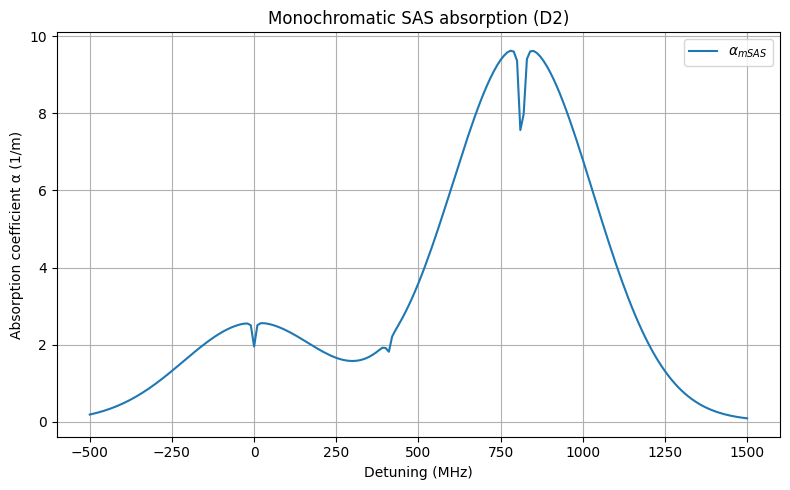

In [8]:
filename = "mSAS_alpha_output_psat.txt"

data = np.loadtxt(filename, skiprows=1)   # skip header line

delta_array_MHz = data[:, 0]
alpha_array = data[:, 1]

plt.figure(figsize=(8,5))
plt.plot(delta_array_MHz, alpha_array, label=r'$\alpha_{mSAS}$')
plt.xlabel('Detuning (MHz)')
plt.ylabel('Absorption coefficient α (1/m)')
plt.title('Monochromatic SAS absorption (D2)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

FWHM guesses (MHz): [501.823938286741, 501.8250221462752]

=== Fitted Parameters ===
Gaussian 1: FWHM = 507.297 MHz
Gaussian 2: FWHM = 509.938 MHz

Lorentzian 1:
Center detuning δ0 ≈ -0.003 MHz
Linewidth FWHM Γ ≈ -18.016 MHz

Lorentzian 2:
Center detuning δ0 ≈ 407.236 MHz
Linewidth FWHM Γ ≈ 21.972 MHz

Lorentzian 3:
Center detuning δ0 ≈ 814.503 MHz
Linewidth FWHM Γ ≈ -27.250 MHz


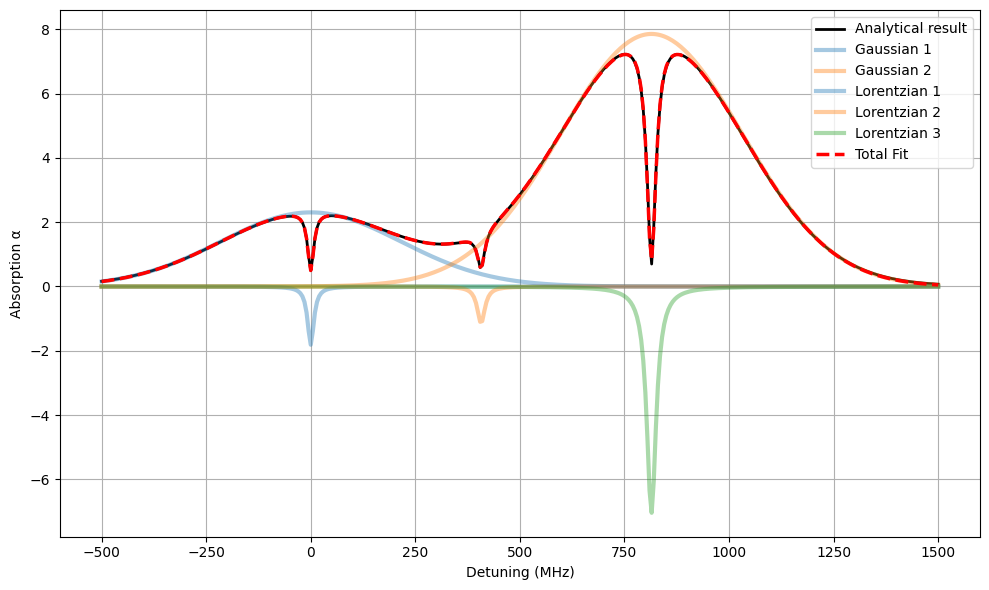

In [18]:
# # Now fitting multiple peaks (Gaussians) and dips (Lorentzians) to the total absorption profile

def compute_alpha0_numeric(delta_array_Hz, N, sigma0, u, lambda0, Gamma2,
                           v_max_factor=7.0, n_v=20001):
    """
    Numerical integration for α₀(δ):
        α₀ = Nσ₀ ∫ f_D(v) L(δ - k_pr*v, Γ₂) dv

    the -infty to infty integral is  approximated as  -v_max_factor * u to v_max_factor * u
    The integral is numerically solved with trapz (n_v is the number of trapezoidal elements) 
    """
    k_freq = 1.0 / lambda0  # in cycles/m instead  of rad/m, because delta is in Hz
    v_max = v_max_factor * u
    v = np.linspace(-v_max, v_max, n_v)
    dv = v[1] - v[0]
    
    alpha0 = np.zeros_like(delta_array_Hz)
    for i, delta in enumerate(delta_array_Hz):
        shifted = lorentzian_unnormalized(delta - k_freq * v, Gamma2)
        integrand = mb_1d_pdf(v, u) * shifted
        integral = np.trapz(integrand, v)
        alpha0[i] = N * sigma0 * integral
    return alpha0

transitions = [
    {"strength":S_coeff_D1_11, "f0": f_D11, "sigma0": sigma_D11_0, "lambda0": lambda_D11, "Gamma": Gamma_D1, "I_sat": I_sat_D11, "label": "F'=1"},
    {"strength":S_coeff_D1_12, "f0": f_D12, "sigma0": sigma_D12_0, "lambda0": lambda_D12, "Gamma": Gamma_D1, "I_sat": I_sat_D12, "label": "F'=2"},
]
zero_f = transitions[0]["f0"]
alpha0_vals = []
for tr in transitions:
    delta_shifted_Hz = delta_array_MHz * 1e6 - (tr["f0"] - zero_f)
    alpha0_vals.append(compute_alpha0_numeric(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma"], v_max_factor=7.0, n_v=20001))

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x-mu)**2 / (2*sigma**2))

def lorentzian(x, A, x0, gamma):
    return A * ( (gamma/2)**2 ) / ( (x-x0)**2 + (gamma/2)**2 )

def total_model(delta, 
                A1, mu1, sigma1,
                A2, mu2, sigma2,
                *lorentz_params):
    # lorentz_params = [A3, x03, gamma3, A4, x04, gamma4, ...]
    result = gaussian(delta, A1, mu1, sigma1) \
           + gaussian(delta, A2, mu2, sigma2)

    # each Lorentzian has 3 parameters
    for j in range(0, len(lorentz_params), 3):
        Aj = lorentz_params[j]
        x0j = lorentz_params[j+1]
        gammaj = lorentz_params[j+2]
        result += lorentzian(delta, Aj, x0j, gammaj)

    return result

# Suppose you know approximate peaks:
guess_gaussians = [
    [np.max(alpha0_vals[0]),  delta_array_MHz[np.argmax(alpha0_vals[0])], u/(np.sqrt(2) * transitions[0]['lambda0']) * 1e-6],   # [A, mu, sigma]
    [np.max(alpha0_vals[1]), delta_array_MHz[np.argmax(alpha0_vals[1])], u/(np.sqrt(2) * transitions[1]['lambda0']) * 1e-6]
]
print("FWHM guesses (MHz):", [2*np.sqrt(2*np.log(2))*g[2] for g in guess_gaussians])

# Suppose you have n lorentzian dips:
lorentz_centers = [(transitions[0]['f0']-zero_f) * 1e-6, ((transitions[0]['f0']-zero_f) + (transitions[1]['f0']-zero_f))/2 * 1e-6, (transitions[1]['f0']-zero_f) * 1e-6]   # <-- your rough guesses
n = len(lorentz_centers)

guess_lorentzians = []
for c in lorentz_centers:
    guess_lorentzians += [-0.4, c, 30]   # [A, x0, gamma]

p0 = []
for g in guess_gaussians:
    p0 += g
p0 += guess_lorentzians

popt, pcov = curve_fit(total_model, delta_array_MHz, alpha_array, p0=p0)

fwhm_gaussians = []
fwhm_lorentzians = []

# Extract
idx = 0
for i in range(2):        # 2 Gaussians
    A, mu, sigma = popt[idx:idx+3]
    fwhm_gaussians.append(2*np.sqrt(2*np.log(2))*sigma)
    idx += 3

for j in range(n):        # n Lorentzians
    A, x0, gamma = popt[idx:idx+3]
    fwhm_lorentzians.append(gamma)
    idx += 3

# Make fitted curve
fit_curve = total_model(delta_array_MHz, *popt)

plt.figure(figsize=(10,6))

# Raw experimental data
plt.plot(delta_array_MHz, alpha_array, 'k', label='Analytical result', lw=2)

# Plot Gaussians
idx = 0
colors = ['tab:blue', 'tab:orange']
for i in range(2):
    A, mu, sigma = popt[idx:idx+3]
    comp = gaussian(delta_array_MHz, A, mu, sigma)
    plt.plot(delta_array_MHz, comp, color=colors[i], alpha=0.4, lw=3,
             label=f"Gaussian {i+1}")
    idx += 3

# Plot Lorentzians
for j in range(n):
    A, x0, gamma = popt[idx:idx+3]
    comp = lorentzian(delta_array_MHz, A, x0, gamma)
    plt.plot(delta_array_MHz, comp, alpha=0.4, lw=3,
             label=f"Lorentzian {j+1}")
    idx += 3

print("\n=== Fitted Parameters ===")
for i in range(2):
    print(f"Gaussian {i+1}: FWHM = {fwhm_gaussians[i]:.3f} MHz")
for j in range(n):
    # print(f"\n==== {transitions[j]['label']} ====")
    print(f"\nLorentzian {j+1}:")
    print(f"Center detuning δ0 ≈ {popt[6+3*j+1]:.3f} MHz")
    print(f"Linewidth FWHM Γ ≈ {popt[6+3*j+2]:.3f} MHz")
    # print(f"expected linewidth Γ_mSAS = {Gamma_mSAS/1e6:.3f} MHz")

# Total fitted model
plt.plot(delta_array_MHz, fit_curve, 'r--', lw=2.5, label='Total Fit')

plt.xlabel("Detuning (MHz)")
plt.ylabel("Absorption α")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
# D2
# ------------------------------
# Part 4: Final assembly + plotting (1x4 pump panels)
# ------------------------------
# ---------- User-tweakable parameters ----------
# Detuning grid (Hz) relative to f_D11 (probe reference)
delta_min_MHz = -750.0
delta_max_MHz = 750.0
n_det = 201   # number of detuning points (increase for smoother curves)
delta_array_MHz = np.linspace(delta_min_MHz, delta_max_MHz, n_det)

# Velocity integration settings (these are heavy)
v_max_factor = 5.0
n_v = 2001    # use 2001 for testing; 20001 for full accuracy is slow

# Cell length for transmittance
L_cell = 0.075   # meters (75 mm)

# Use intensities (converted from mW/cm^2 as in your inputs)
I_pr_Wm2 = 0.03e-3 / 1e-4   # 0.03 mW/cm^2 -> W/m^2
I_pu_Wm2 = 0.22e-3  / 1e-4   # 1.3 mW/cm^2 -> W/m^2

# Which pump wavelengths to use (D2 F'=0..3)
pump_labels = [r"F' = 0", r"F' = 1", r"F' = 12", r"F' = 2"]
pump_freqs = [f_D20, f_D21, (f_D21+f_D22)/2, f_D22]   # Hz
pump_lambdas = [c/f for f in pump_freqs]  # m

# D1 probe wavelength (we probe S1/2 F=1 -> P1/2 F'=1 as reference)
lambda_probe_ref = lambda_D21
f_probe_ref = f_D21

# Which individual D1 contributions to optionally show
show_components = True

# ---------- build detuning array (Hz) ----------
# delta_array_MHz = np.linspace(delta_min_MHz, delta_max_MHz, n_det)
# delta_array_MHz = np.array([750])  # single point test
delta_array_Hz = delta_array_MHz * 1e6

# ---------- compute the Doppler-averaged background mSAS alpha (slow) ----------
print("computing Doppler-averaged alpha (mSAS).")
print(f" detuning range: {delta_min_MHz} .. {delta_max_MHz} MHz, points = {n_det}")
print(f" velocity grid n_v = {n_v}, v_max_factor = {v_max_factor}")
t0 = time()
# compute_mSAS_alpha should be defined in Part 2
alpha_array = compute_mSAS_alpha_D2(
    delta_array_Hz,
    N,                # total number density (m^-3) for the isotope 
    I_pr_Wm2,
    I_pu_Wm2,
    v_max_factor=v_max_factor,
    n_v=n_v,
    t_end_factor=400.0 # should be 800
)
t1 = time()
print(f" Done alpha0 calculation in {t1 - t0:.1f} s")
delta_array_MHz = delta_array_Hz / 1e6

# ------------------------------
# Save detuning and alpha to TXT
# ------------------------------
output_filename = "mSAS_alpha_output_D2_psat.txt"

# Stack into two columns: detuning (MHz) and alpha (1/m)
data_to_save = np.column_stack([delta_array_MHz, alpha_array])

np.savetxt(
    output_filename,
    data_to_save,
    fmt="%.6e",
    header="Detuning_MHz    Alpha_per_m",
    comments=""
)

print(f"Saved mSAS D2 α(Δ) to {output_filename}")



computing Doppler-averaged alpha (mSAS).
 detuning range: -750.0 .. 750.0 MHz, points = 201
 velocity grid n_v = 2001, v_max_factor = 5.0
mSAS: computed 1/201 detunings
mSAS: computed 21/201 detunings
mSAS: computed 41/201 detunings
mSAS: computed 61/201 detunings
mSAS: computed 81/201 detunings
mSAS: computed 101/201 detunings
mSAS: computed 121/201 detunings
mSAS: computed 141/201 detunings
mSAS: computed 161/201 detunings
mSAS: computed 181/201 detunings
mSAS: computed 201/201 detunings
 Done alpha0 calculation in 1592.8 s
Saved mSAS D2 α(Δ) to mSAS_alpha_output_D2_psat.txt


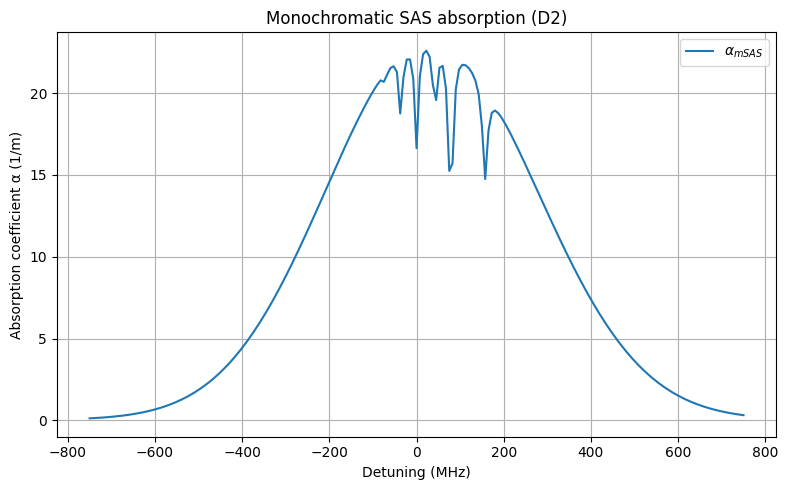

In [10]:
filename = "mSAS_alpha_output_D2_psat.txt"

data = np.loadtxt(filename, skiprows=1)   # skip header line

delta_array_MHz = data[:, 0]
alpha_array = data[:, 1]

plt.figure(figsize=(8,5))
plt.plot(delta_array_MHz, alpha_array, label=r'$\alpha_{mSAS}$')
plt.xlabel('Detuning (MHz)')
plt.ylabel('Absorption coefficient α (1/m)')
plt.title('Monochromatic SAS absorption (D2)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

FWHM guesses (MHz): [513.9801865827666, 513.98028318686, 513.9804931306782]
Lorentzian centers (MHz): [-72.218, -36.109, 42.3645, 0.0, 78.4735, 156.947]

=== Fitted Parameters ===
Gaussian 1: FWHM = 538.710 MHz
Gaussian 2: FWHM = 513.334 MHz
Gaussian 3: FWHM = 529.396 MHz

Lorentzian 1:
Center detuning δ0 ≈ -72.220 MHz
Linewidth FWHM Γ ≈ 9.208 MHz
natural linewidth = 6.067 MHz

Lorentzian 2:
Center detuning δ0 ≈ -36.163 MHz
Linewidth FWHM Γ ≈ 15.733 MHz
natural linewidth = 6.067 MHz

Lorentzian 3:
Center detuning δ0 ≈ 42.315 MHz
Linewidth FWHM Γ ≈ 25.598 MHz
natural linewidth = 6.067 MHz

Lorentzian 4:
Center detuning δ0 ≈ -0.023 MHz
Linewidth FWHM Γ ≈ 17.952 MHz
natural linewidth = 6.067 MHz

Lorentzian 5:
Center detuning δ0 ≈ 78.450 MHz
Linewidth FWHM Γ ≈ 23.499 MHz
natural linewidth = 6.067 MHz

Lorentzian 6:
Center detuning δ0 ≈ 156.961 MHz
Linewidth FWHM Γ ≈ 25.309 MHz
natural linewidth = 6.067 MHz

average ratio Γ_mSAS / natural linewidth =  3.222564328051672


C:\Users\Dell\AppData\Local\Temp\ipykernel_4072\2175262867.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(total_model, delta_array_MHz, alpha_array, p0=p0, maxfev=50000)


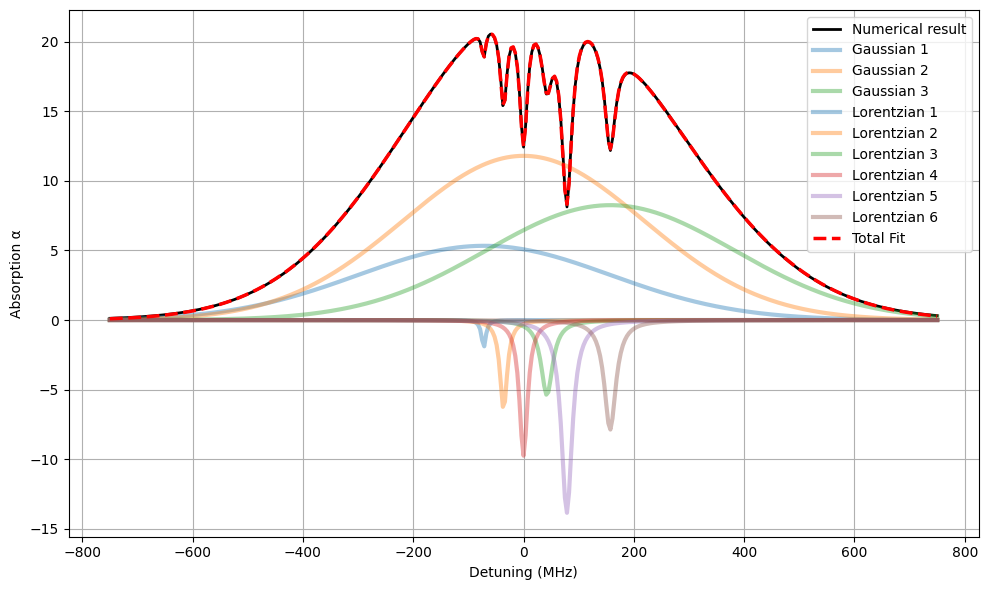

In [6]:
# # Now fitting multiple peaks (Gaussians) and dips (Lorentzians) to the total absorption profile

def compute_alpha0_numeric(delta_array_Hz, N, sigma0, u, lambda0, Gamma2,
                           v_max_factor=7.0, n_v=20001):
    """
    Numerical integration for α₀(δ):
        α₀ = Nσ₀ ∫ f_D(v) L(δ - k_pr*v, Γ₂) dv

    the -infty to infty integral is  approximated as  -v_max_factor * u to v_max_factor * u
    The integral is numerically solved with trapz (n_v is the number of trapezoidal elements) 
    """
    k_freq = 1.0 / lambda0  # in cycles/m instead  of rad/m, because delta is in Hz
    v_max = v_max_factor * u
    v = np.linspace(-v_max, v_max, n_v)
    dv = v[1] - v[0]
    
    alpha0 = np.zeros_like(delta_array_Hz)
    for i, delta in enumerate(delta_array_Hz):
        shifted = lorentzian_unnormalized(delta - k_freq * v, Gamma2)
        integrand = mb_1d_pdf(v, u) * shifted
        integral = np.trapz(integrand, v)
        alpha0[i] = N * sigma0 * integral
    return alpha0

transitions = [
    {"strength":S_coeff_D2_10, "f0": f_D20, "sigma0": sigma_D20_0, "lambda0": lambda_D20, "Gamma": Gamma_D2, "I_sat": I_sat_D20, "label": "F'=0"},
    {"strength":S_coeff_D2_11, "f0": f_D21, "sigma0": sigma_D21_0, "lambda0": lambda_D21, "Gamma": Gamma_D2, "I_sat": I_sat_D21, "label": "F'=1"},
    {"strength":S_coeff_D2_12, "f0": f_D22, "sigma0": sigma_D22_0, "lambda0": lambda_D22, "Gamma": Gamma_D2, "I_sat": I_sat_D22, "label": "F'=2"},
]
zero_f = transitions[1]["f0"]
alpha0_vals = []
for tr in transitions:
    delta_shifted_Hz = delta_array_MHz * 1e6 - (tr["f0"] - zero_f)
    alpha0_vals.append(3*compute_alpha0_numeric(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma"], v_max_factor=7.0, n_v=20001))

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x-mu)**2 / (2*sigma**2))

def lorentzian(x, A, x0, gamma):
    return A * ( (gamma/2)**2 ) / ( (x-x0)**2 + (gamma/2)**2 )

def total_model(delta, 
                A1, mu1, sigma1,
                A2, mu2, sigma2,
                A3, mu3, sigma3,
                *lorentz_params):
    # lorentz_params = [A3, x03, gamma3, A4, x04, gamma4, ...]
    result = gaussian(delta, A1, delta_array_MHz[np.argmax(alpha0_vals[0])], sigma1) \
           + gaussian(delta, A2, delta_array_MHz[np.argmax(alpha0_vals[1])], sigma2) \
           + gaussian(delta, A3, delta_array_MHz[np.argmax(alpha0_vals[2])], sigma3)

    # each Lorentzian has 3 parameters
    for j in range(0, len(lorentz_params), 3):
        Aj = lorentz_params[j]
        x0j = lorentz_params[j+1]
        gammaj = lorentz_params[j+2]
        result += lorentzian(delta, Aj, x0j, gammaj)

    return result

# Suppose you know approximate peaks:
guess_gaussians = [
    [np.max(alpha0_vals[0]),  delta_array_MHz[np.argmax(alpha0_vals[0])], u/(np.sqrt(2) * transitions[0]['lambda0']) * 1e-6],   # [A, mu, sigma]
    [np.max(alpha0_vals[1]), delta_array_MHz[np.argmax(alpha0_vals[1])], u/(np.sqrt(2) * transitions[1]['lambda0']) * 1e-6],
    [np.max(alpha0_vals[2]), delta_array_MHz[np.argmax(alpha0_vals[2])], u/(np.sqrt(2) * transitions[2]['lambda0']) * 1e-6]
]
print("FWHM guesses (MHz):", [2*np.sqrt(2*np.log(2))*g[2] for g in guess_gaussians])

# Suppose you have n lorentzian dips:
lorentz_centers = [(transitions[i]['f0']+transitions[j]['f0']-2*zero_f)/2 * 1e-6 for i in range(len(transitions)) for j in range(i, len(transitions))]   # <-- your rough guesses
print("Lorentzian centers (MHz):", lorentz_centers)
n = len(lorentz_centers)

guess_lorentzians = []
for c in lorentz_centers:
    guess_lorentzians += [-2.5, c, 30]   # [A, x0, gamma]

p0 = []
for g in guess_gaussians:
    p0 += g
p0 += guess_lorentzians

popt, pcov = curve_fit(total_model, delta_array_MHz, alpha_array, p0=p0, maxfev=50000)

fwhm_gaussians = []
fwhm_lorentzians = []

# Extract
idx = 0
for i in range(3):        # 3 Gaussians
    A, mu, sigma = popt[idx:idx+3]
    fwhm_gaussians.append(2*np.sqrt(2*np.log(2))*sigma)
    idx += 3

for j in range(n):        # n Lorentzians
    A, x0, gamma = popt[idx:idx+3]
    fwhm_lorentzians.append(gamma)
    idx += 3

# Make fitted curve
fit_curve = total_model(delta_array_MHz, *popt)

plt.figure(figsize=(10,6))

# Raw experimental data
plt.plot(delta_array_MHz, alpha_array, 'k', label='Numerical result', lw=2)

# Plot Gaussians
idx = 0
colors = ['tab:blue', 'tab:orange', 'tab:green']
for i in range(3):
    A, mu, sigma = popt[idx:idx+3]
    comp = gaussian(delta_array_MHz, A, mu, sigma)
    plt.plot(delta_array_MHz, comp, color=colors[i], alpha=0.4, lw=3,
             label=f"Gaussian {i+1}")
    idx += 3

# Plot Lorentzians
for j in range(n):
    A, x0, gamma = popt[idx:idx+3]
    comp = lorentzian(delta_array_MHz, A, x0, gamma)
    plt.plot(delta_array_MHz, comp, alpha=0.4, lw=3,
             label=f"Lorentzian {j+1}")
    idx += 3

print("\n=== Fitted Parameters ===")
for i in range(3):
    print(f"Gaussian {i+1}: FWHM = {np.abs(fwhm_gaussians[i]):.3f} MHz")
for j in range(n):
    # print(f"\n==== {transitions[j]['label']} ====")
    print(f"\nLorentzian {j+1}:")
    print(f"Center detuning δ0 ≈ {popt[9+3*j+1]:.3f} MHz")
    print(f"Linewidth FWHM Γ ≈ {np.abs(popt[9+3*j+2]):.3f} MHz")
    # print(f"expected linewidth Γ_mSAS = {Gamma_mSAS/1e6:.3f} MHz")
    print(f"natural linewidth = {(Gamma_D2)/1e6:.3f} MHz")

print()
print("average ratio Γ_mSAS / natural linewidth = ",
      np.mean([np.abs(popt[9+3*j+2])/(Gamma_D2/1e6) for j in range(n)]))

# Total fitted model
plt.plot(delta_array_MHz, fit_curve, 'r--', lw=2.5, label='Total Fit')

plt.xlabel("Detuning (MHz)")
plt.ylabel("Absorption α")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### bSAS

In [9]:
# the one used in locking in the genov paper

# ------------------------------
# Part 4: Final assembly + plotting (1x4 pump panels)
# ------------------------------

# ---------- User-tweakable parameters ----------
# Detuning grid (Hz) relative to f_D11 (probe reference)
range_MHz = [-250, 250]
delta_min_MHz = range_MHz[0] + f_p12F1_to_P12F2 / 1e6
delta_max_MHz = range_MHz[1] + f_p12F1_to_P12F2 / 1e6
n_det = 401   # number of detuning points (increase for smoother curves)

# Velocity integration settings (these are heavy)
v_max_factor = 7.0
n_v = 2001    # use 2001 for testing; 20001 for full accuracy is slow

# Cell length for transmittance
L_cell = 0.075   # meters (75 mm)

# Use intensities (converted from mW/cm^2 as in your inputs)
I_pr_Wm2 = 0.04 * 6.2e-3 / 1e-4   # 0.03 mW/cm^2 -> W/m^2
I_pu_Wm2 = 6.2e-3  / 1e-4   # 1.3 mW/cm^2 -> W/m^2

# Which pump wavelengths to use (D2 F'=0..3)
pump_labels = r"F' = 12"
pump_freqs = (f_D21+f_D22)/2   # Hz
pump_lambdas = c/pump_freqs  # m

# D1 probe wavelength (we probe S1/2 F=1 -> P1/2 F'=1 as reference)
lambda_probe_ref = lambda_D11
f_probe_ref = f_D11

# Which individual D1 contributions to optionally show
show_components = True

# ---------- build detuning array (Hz) ----------
delta_array_MHz = np.linspace(delta_min_MHz, delta_max_MHz, n_det)
delta_array_Hz = delta_array_MHz * 1e6

# ---------- compute the Doppler-averaged background mSAS alpha (slow) ----------
print("computing Doppler-averaged alpha (bSAS).")
print(f" detuning range: {delta_min_MHz} .. {delta_max_MHz} MHz, points = {n_det}")
print(f" velocity grid n_v = {n_v}, v_max_factor = {v_max_factor}")
t0 = time()
# compute_mSAS_alpha should be defined in Part 2

print(f" Computing for pump {pump_labels} at lambda = {pump_lambdas*1e9:.2f} nm")
alpha_i, N1_v, N3_v, N4_v, N1_0_array, N2_0_array = compute_bSAS_alpha(
    delta_array_Hz,
    pump_freqs,
    N,                # total number density (m^-3) for the isotope (as in your constants)
    I_pr_Wm2,
    I_pu_Wm2,
    v_max_factor=v_max_factor,
    n_v=n_v,
    t_end_factor=400.0
)
t1 = time()
print(f" Done alpha calculation in {t1 - t0:.1f} s")
delta_array_MHz = delta_array_Hz / 1e6

# ------------------------------
# Save detuning and alpha to TXT
# ------------------------------
output_directory = "bSAS_stabil_ref_output"
output_filename = ["alpha.txt", "N1_v.txt", "N3_v.txt", "N4_v.txt", "N1_0.txt", "N2_0.txt"]

# save to txt files
import os
os.makedirs(output_directory, exist_ok=True)

# take a single pump case (index 0) for saving
# data is saved with a detuning for each line and a speed for each column (for the velocity-resolved arrays)
data_to_save = np.column_stack([delta_array_MHz, alpha_i])

np.savetxt(
    os.path.join(output_directory, output_filename[0]),
    data_to_save,
    fmt="%.6e",
    header="Detuning_MHz    Alpha_per_m",
    comments=""
)

np.savetxt(
    os.path.join(output_directory, output_filename[1]),
    np.array(N1_v),
    fmt="%.6e",
    # header="Detuning_MHz    N1_v    N3_v    N4_v", # no header 
    # comments=""
)
np.savetxt(
    os.path.join(output_directory, output_filename[2]),
    np.array(N3_v),
    fmt="%.6e",
)
np.savetxt(
    os.path.join(output_directory, output_filename[3]),
    np.array(N4_v),
    fmt="%.6e",
)
np.savetxt(
    os.path.join(output_directory, output_filename[4]),
    np.array(N1_0_array),
    fmt="%.6e",
)
np.savetxt(
    os.path.join(output_directory, output_filename[5]),
    np.array(N2_0_array),
    fmt="%.6e",
)

print(f"Saved bSAS α(Δ) and velocity-resolved arrays to {output_directory}")


computing Doppler-averaged alpha (bSAS).
 detuning range: 564.5 .. 1064.5 MHz, points = 401
 velocity grid n_v = 2001, v_max_factor = 7.0
 Computing for pump F' = 12 at lambda = 780.23 nm
bSAS: computed 1/401 detunings
bSAS: computed 41/401 detunings
bSAS: computed 81/401 detunings
bSAS: computed 121/401 detunings
bSAS: computed 161/401 detunings
bSAS: computed 201/401 detunings
bSAS: computed 241/401 detunings
bSAS: computed 281/401 detunings
bSAS: computed 321/401 detunings
bSAS: computed 361/401 detunings
bSAS: computed 401/401 detunings
 Done alpha calculation in 0.3 s
Saved bSAS α(Δ) and velocity-resolved arrays to bSAS_stabil_ref_output


In [ ]:
# ------------------------------
# Part 4: Final assembly + plotting (1x4 pump panels)
# ------------------------------

# ---------- User-tweakable parameters ----------
# Detuning grid (Hz) relative to f_D11 (probe reference)
delta_min_MHz = -500.0
delta_max_MHz = 1500.0
n_det = 401   # number of detuning points (increase for smoother curves)

# Velocity integration settings (these are heavy)
v_max_factor = 7.0
n_v = 2001    # use 2001 for testing; 20001 for full accuracy is slow

# Cell length for transmittance
L_cell = 0.075   # meters (75 mm)

# Use intensities (converted from mW/cm^2 as in your inputs)
I_pr_Wm2 = 0.04 * 6.2e-3 / 1e-4   # 0.03 mW/cm^2 -> W/m^2
I_pu_Wm2 = 6.2e-3  / 1e-4   # 1.3 mW/cm^2 -> W/m^2

# Which pump wavelengths to use (D2 F'=0..3)
pump_labels = [r"F' = 0", r"F' = 1", r"F' = 12", r"F' = 2"]
pump_freqs = [f_D20, f_D21, (f_D21+f_D22)/2, f_D22]   # Hz
pump_lambdas = [c/f for f in pump_freqs]  # m

# D1 probe wavelength (we probe S1/2 F=1 -> P1/2 F'=1 as reference)
lambda_probe_ref = lambda_D11
f_probe_ref = f_D11

# Which individual D1 contributions to optionally show
show_components = True

# ---------- build detuning array (Hz) ----------
delta_array_MHz = np.linspace(delta_min_MHz, delta_max_MHz, n_det)
delta_array_Hz = delta_array_MHz * 1e6

# ---------- compute the Doppler-averaged background mSAS alpha (slow) ----------
print("computing Doppler-averaged alpha (bSAS).")
print(f" detuning range: {delta_min_MHz} .. {delta_max_MHz} MHz, points = {n_det}")
print(f" velocity grid n_v = {n_v}, v_max_factor = {v_max_factor}")
t0 = time()
# compute_mSAS_alpha should be defined in Part 2

alpha_array = []
for i in range(len(pump_freqs)):
    print(f" Computing for pump {pump_labels[i]} at lambda = {pump_lambdas[i]*1e9:.2f} nm")
    alpha_i = compute_bSAS_alpha(
        delta_array_Hz,
        pump_freqs[i],
        N,                # total number density (m^-3) for the isotope (as in your constants)
        I_pr_Wm2,
        I_pu_Wm2,
        v_max_factor=v_max_factor,
        n_v=n_v,
        t_end_factor=400.0
    )
    alpha_array.append(alpha_i)
t1 = time()
print(f" Done alpha0 calculation in {t1 - t0:.1f} s")
delta_array_MHz = delta_array_Hz / 1e6

# ------------------------------
# Save detuning and alpha to TXT
# ------------------------------
output_filename = "bSAS_alpha_output_test.txt"

# Stack into two columns: detuning (MHz) and alpha (1/m)
data_to_save = np.column_stack([delta_array_MHz, alpha_array[0], alpha_array[1], alpha_array[2], alpha_array[3]])

np.savetxt(
    output_filename,
    data_to_save,
    fmt="%.6e",
    header="Detuning_MHz    Alpha_per_m",
    comments=""
)

print(f"Saved bSAS α(Δ) to {output_filename}")



computing Doppler-averaged alpha (bSAS).
 detuning range: -500.0 .. 1500.0 MHz, points = 401
 velocity grid n_v = 2001, v_max_factor = 7.0
 Computing for pump F' = 0 at lambda = 0.00 nm


KeyboardInterrupt: 

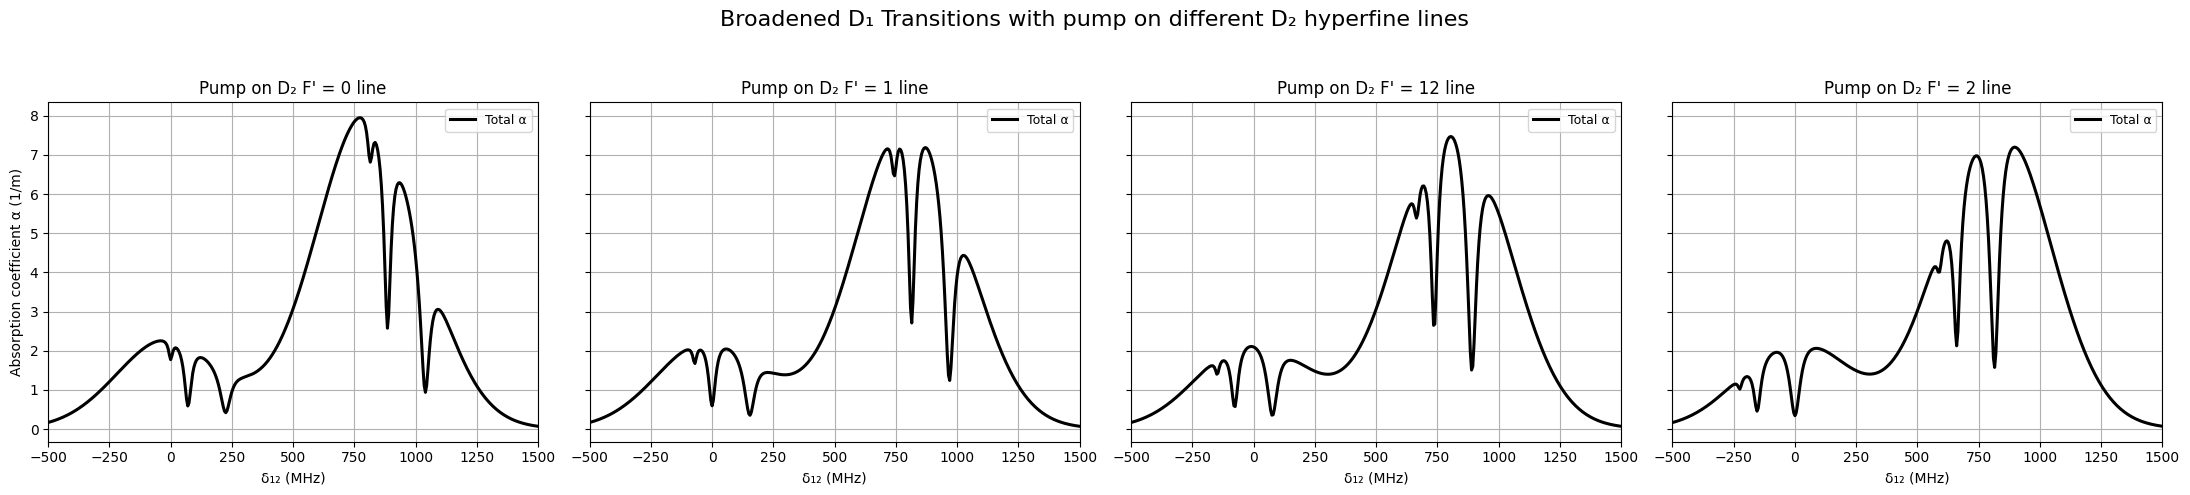

In [7]:
filename = "bSAS_alpha_output.txt"
pump_labels = [r"F' = 0", r"F' = 1", r"F' = 12", r"F' = 2"]
pump_freqs = [f_D20, f_D21, (f_D21+f_D22)/2, f_D22]   # Hz
pump_lambdas = [c/f for f in pump_freqs]  # m

data = np.loadtxt(filename, skiprows=1)   # skip header line

delta_array_MHz = data[:, 0]
alpha_array = [data[:, 1], data[:, 2], data[:, 3], data[:, 4]]

# --- 1×4 comparison: pump on D2 F'=0,1,2,3 --------------------------
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
for i, ax in enumerate(axes):
    
    # total absorption (black thick line)
    ax.plot(delta_array_MHz, alpha_array[i], "k", lw=2.2, label="Total α")

    ax.set_title(fr"Pump on D₂ {pump_labels[i]} line")
    ax.set_xlabel(r"δ₁₂ (MHz)")
    ax.grid(True)
    ax.legend(fontsize=9)
    ax.set_xlim(-500, 1500)  # zoom region where lamb dip visible

axes[0].set_ylabel(r"Absorption coefficient α (1/m)")
fig.suptitle("Broadened D₁ Transitions with pump on different D₂ hyperfine lines", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


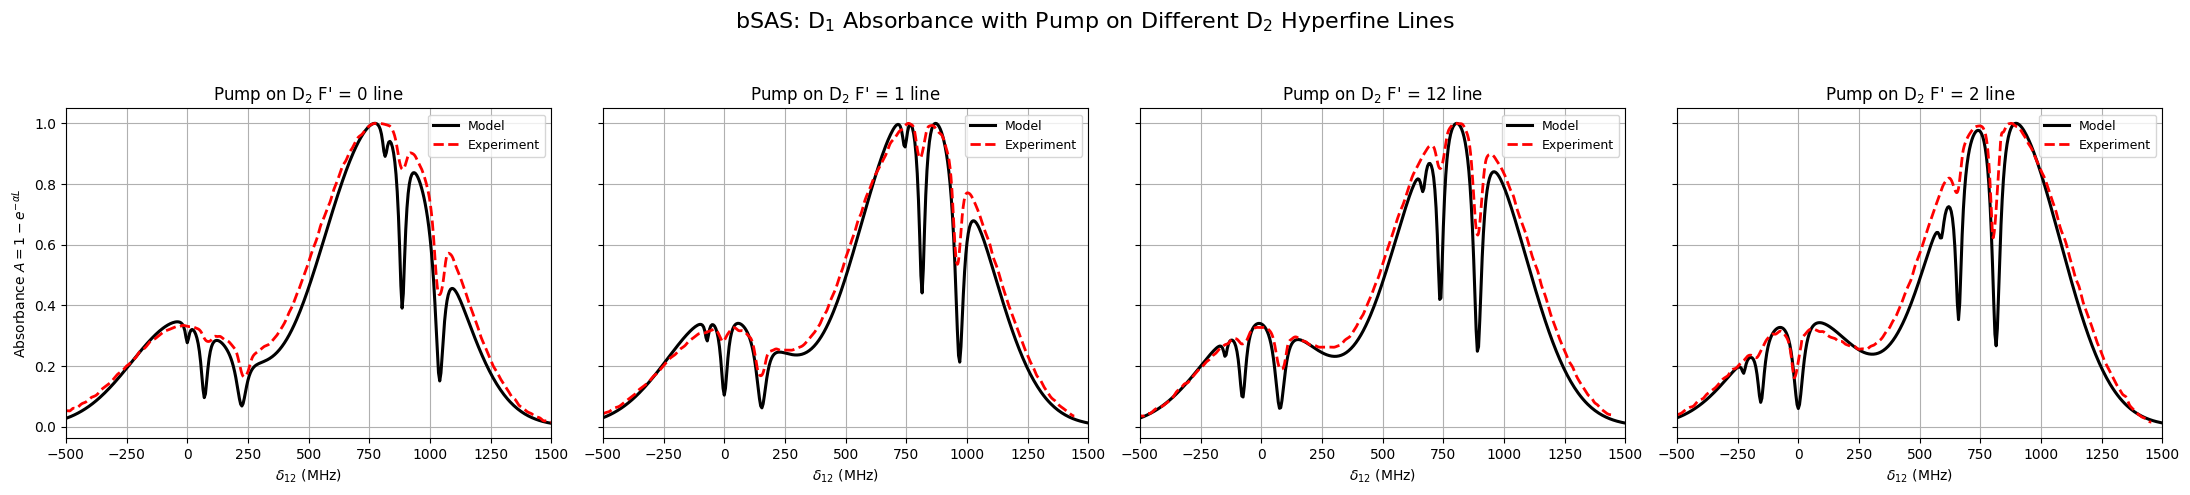

In [5]:
# ===============================
# Parameters
# ===============================
L_cell = 75e-3  # m

filename = "bSAS_alpha_output.txt"

pump_labels = [r"F' = 0", r"F' = 1", r"F' = 12", r"F' = 2"]

exp_files = [
    "../fig_to_txt/genov bSAS eks F=0.csv",
    "../fig_to_txt/genov bSAS eks F=1.csv",
    "../fig_to_txt/genov bSAS eks F=12.csv",
    "../fig_to_txt/genov bSAS eks F=2.csv",
]

# ===============================
# Load numerical data
# ===============================
data = np.loadtxt(filename, skiprows=1)

delta_array_MHz = data[:, 0]
alpha_array = [
    data[:, 1],
    data[:, 2],
    data[:, 3],
    data[:, 4],
]

# Convert numerical α → absorbance
A_numeric = [
    1.0 - np.exp(-alpha * L_cell)
    for alpha in alpha_array
]
A_numeric = [A / np.max(A) for A in A_numeric]  # normalize to max of first trace

# ===============================
# Figure: 1×4 panels
# ===============================
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

for i, ax in enumerate(axes):

    # ---- Numerical model ----
    ax.plot(
        delta_array_MHz,
        A_numeric[i],
        "k",
        lw=2.2,
        label="Model"
    )

    # ---- Experimental data ----
    exp_data = np.loadtxt(exp_files[i], delimiter=",")
    delta_exp = exp_data[:, 0]
    A_exp = exp_data[:, 1]

    # normalize experimental trace (consistent with previous figures)
    A_exp = A_exp / np.max(A_exp)

    ax.plot(
        delta_exp,
        A_exp,
        "r--",
        lw=2.0,
        label="Experiment"
    )

    ax.set_title(fr"Pump on D$_2$ {pump_labels[i]} line")
    ax.set_xlabel(r"$\delta_{12}$ (MHz)")
    ax.set_xlim(-500, 1500)
    ax.grid(True)
    ax.legend(fontsize=9)

# Shared y-axis
axes[0].set_ylabel(r"Absorbance $A = 1 - e^{-\alpha L}$")

fig.suptitle(
    "bSAS: D$_1$ Absorbance with Pump on Different D$_2$ Hyperfine Lines",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


FWHM guesses (MHz): [504.45163427281096, 504.4527238077488]
Lorentzian center guesses (MHz): [0.0, 70.87916825378917, 224.91656640836905, 814.5, 885.3793213414688, 1039.4170521922192]

=== Fitted Parameters ===
Gaussian 1: FWHM = 505.891 MHz
Gaussian 2: FWHM = 555.955 MHz

Lorentzian 1:
Center detuning δ0 ≈ -0.075 MHz
Linewidth FWHM Γ ≈ 19.521 MHz

Lorentzian 2:
Center detuning δ0 ≈ 70.407 MHz
Linewidth FWHM Γ ≈ 31.988 MHz

Lorentzian 3:
Center detuning δ0 ≈ 223.395 MHz
Linewidth FWHM Γ ≈ 46.368 MHz

Lorentzian 4:
Center detuning δ0 ≈ 814.413 MHz
Linewidth FWHM Γ ≈ 35.343 MHz

Lorentzian 5:
Center detuning δ0 ≈ 885.252 MHz
Linewidth FWHM Γ ≈ 32.555 MHz

Lorentzian 6:
Center detuning δ0 ≈ 1038.178 MHz
Linewidth FWHM Γ ≈ 43.048 MHz

average ratio Γ_bSAS / natural linewidth =  5.736963435399748


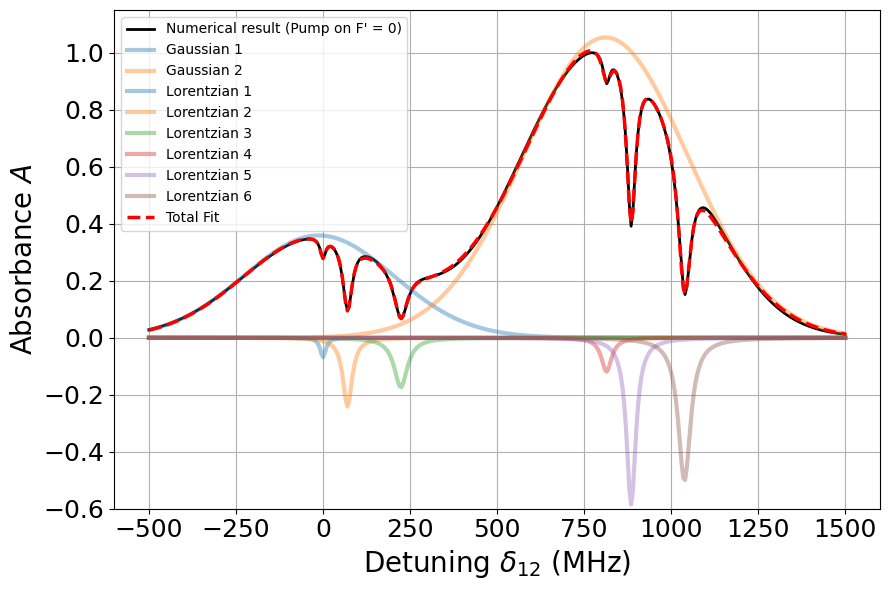

In [15]:
# # Now fitting multiple peaks (Gaussians) and dips (Lorentzians) to the total absorption profile
CHOSEN_PUMP_INDEX = 0  # index of pump to analyze (0 to 3)
L_cell = 75e-3  # m
A_array = 1- np.exp(-alpha_array[CHOSEN_PUMP_INDEX] * L_cell)  # absorbance
A_array = A_array / np.max(A_array)  # normalize to max of first trace
def compute_alpha0_numeric(delta_array_Hz, N, sigma0, u, lambda0, Gamma2,
                           v_max_factor=7.0, n_v=20001):
    """
    Numerical integration for α₀(δ):
        α₀ = Nσ₀ ∫ f_D(v) L(δ - k_pr*v, Γ₂) dv

    the -infty to infty integral is  approximated as  -v_max_factor * u to v_max_factor * u
    The integral is numerically solved with trapz (n_v is the number of trapezoidal elements) 
    """
    k_freq = 1.0 / lambda0  # in cycles/m instead  of rad/m, because delta is in Hz
    v_max = v_max_factor * u
    v = np.linspace(-v_max, v_max, n_v)
    dv = v[1] - v[0]
    
    alpha0 = np.zeros_like(delta_array_Hz)
    for i, delta in enumerate(delta_array_Hz):
        shifted = lorentzian_unnormalized(delta - k_freq * v, Gamma2)
        integrand = mb_1d_pdf(v, u) * shifted
        integral = np.trapz(integrand, v)
        alpha0[i] = N * sigma0 * integral
    return alpha0

transitions = [
    {"strength":S_coeff_D1_11, "f0": f_D11, "sigma0": sigma_D11_0, "lambda0": lambda_D11, "Gamma": Gamma_D1, "I_sat": I_sat_D11, "label": "F'=1"},
    {"strength":S_coeff_D1_12, "f0": f_D12, "sigma0": sigma_D12_0, "lambda0": lambda_D12, "Gamma": Gamma_D1, "I_sat": I_sat_D12, "label": "F'=2"},
]
zero_f = transitions[0]["f0"]
alpha0_vals = []
for tr in transitions:
    delta_shifted_Hz = delta_array_MHz * 1e6 - (tr["f0"] - zero_f)
    alpha0_vals.append(compute_alpha0_numeric(delta_shifted_Hz, N, tr["sigma0"], u, tr["lambda0"], tr["Gamma"], v_max_factor=7.0, n_v=20001))

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x-mu)**2 / (2*sigma**2))

def lorentzian(x, A, x0, gamma):
    return A * ( (gamma/2)**2 ) / ( (x-x0)**2 + (gamma/2)**2 )

def total_model(delta, 
                A1, mu1, sigma1,
                A2, mu2, sigma2,
                *lorentz_params):
    # lorentz_params = [A3, x03, gamma3, A4, x04, gamma4, ...]
    result = gaussian(delta, A1, mu1, sigma1) \
           + gaussian(delta, A2, mu2, sigma2)

    # each Lorentzian has 3 parameters
    for j in range(0, len(lorentz_params), 3):
        Aj = lorentz_params[j]
        x0j = lorentz_params[j+1]
        gammaj = lorentz_params[j+2]
        result += lorentzian(delta, Aj, x0j, gammaj)

    return result

# Suppose you know approximate peaks:
guess_gaussians = [
    [np.max(alpha0_vals[0]),  delta_array_MHz[np.argmax(alpha0_vals[0])], u/(np.sqrt(2) * transitions[0]['lambda0']) * 1e-6],   # [A, mu, sigma]
    [np.max(alpha0_vals[1]), delta_array_MHz[np.argmax(alpha0_vals[1])], u/(np.sqrt(2) * transitions[1]['lambda0']) * 1e-6]
]
print("FWHM guesses (MHz):", [2*np.sqrt(2*np.log(2))*g[2] for g in guess_gaussians])

# Suppose you have n lorentzian dips:
lorentz_centers = [[] for _ in range(len(pump_labels))]
for i in range(len(pump_labels)):
    lorentz_centers[i] = [((f_D11-zero_f) - (pump_freqs[i] - f_D20) * (pump_lambdas[i]/lambda_D11)) * 1e-6, ((f_D11-zero_f) - (pump_freqs[i] - f_D21) * (pump_lambdas[i]/lambda_D11)) * 1e-6, ((f_D11-zero_f) - (pump_freqs[i] - f_D22) * (pump_lambdas[i]/lambda_D11)) * 1e-6,# D1 F'=1 dip position due to pump on D2 F'=i
                          ((f_D12-zero_f) - (pump_freqs[i] - f_D20) * (pump_lambdas[i]/lambda_D12)) * 1e-6, ((f_D12-zero_f) - (pump_freqs[i] - f_D21) * (pump_lambdas[i]/lambda_D12)) * 1e-6, ((f_D12-zero_f) - (pump_freqs[i] - f_D22) * (pump_lambdas[i]/lambda_D12)) * 1e-6]   # D1 F'=2 dip position due to pump on D2 F'=i
# overwrite
# lorentz_centers[3] = [((f_D11-zero_f) - (pump_freqs[3] - f_D20) * (pump_lambdas[3]/lambda_D11)) * 1e-6, ((f_D11-zero_f) - (pump_freqs[3] - f_D21) * (pump_lambdas[3]/lambda_D11)) * 1e-6, ((f_D11-zero_f) - (pump_freqs[3] - f_D22) * (pump_lambdas[3]/lambda_D11)) * 1e-6,# D1 F'=1 dip position due to pump on D2 F'=i
#                         ((f_D12-zero_f) - (pump_freqs[3] - f_D20) * (pump_lambdas[3]/lambda_D12)) * 1e-6, ((f_D12-zero_f) - (pump_freqs[3] - f_D21) * (pump_lambdas[3]/lambda_D12)) * 1e-6, ((f_D12-zero_f) - (pump_freqs[3] - f_D22) * (pump_lambdas[3]/lambda_D12)) * 1e-6]

n = len(lorentz_centers[CHOSEN_PUMP_INDEX])
print("Lorentzian center guesses (MHz):", lorentz_centers[CHOSEN_PUMP_INDEX])

guess_lorentzians = []
for c in lorentz_centers[CHOSEN_PUMP_INDEX]:
    guess_lorentzians += [-0.4, c, 30]   # [A, x0, gamma]
# guess_lorentzians = []
# guess_lorentzians += [-0.1, lorentz_centers[CHOSEN_PUMP_INDEX][0], 30]
# guess_lorentzians += [-0.4, lorentz_centers[CHOSEN_PUMP_INDEX][1], 30]
# guess_lorentzians += [-0.4, lorentz_centers[CHOSEN_PUMP_INDEX][2], 30]
# guess_lorentzians += [-0.3, lorentz_centers[CHOSEN_PUMP_INDEX][3], 30]
# guess_lorentzians += [-0.4, lorentz_centers[CHOSEN_PUMP_INDEX][4], 30]
# guess_lorentzians += [-0.4, lorentz_centers[CHOSEN_PUMP_INDEX][5], 30]


p0 = []
for g in guess_gaussians:
    p0 += g
p0 += guess_lorentzians

popt, pcov = curve_fit(total_model, delta_array_MHz, A_array, p0=p0, maxfev=50000)

fwhm_gaussians = []
fwhm_lorentzians = []

# Extract
idx = 0
for i in range(2):        # 2 Gaussians
    A, mu, sigma = popt[idx:idx+3]
    fwhm_gaussians.append(2*np.sqrt(2*np.log(2))*sigma)
    idx += 3

for j in range(n):        # n Lorentzians
    A, x0, gamma = popt[idx:idx+3]
    fwhm_lorentzians.append(gamma)
    idx += 3

# Make fitted curve
fit_curve = total_model(delta_array_MHz, *popt)

plt.figure(figsize=(9,6))

# Raw experimental data
plt.plot(delta_array_MHz, A_array, 'k', label=f'Numerical result (Pump on {pump_labels[CHOSEN_PUMP_INDEX]})', lw=2)

# Plot Gaussians
idx = 0
colors = ['tab:blue', 'tab:orange']
for i in range(2):
    A, mu, sigma = popt[idx:idx+3]
    comp = gaussian(delta_array_MHz, A, mu, sigma)
    plt.plot(delta_array_MHz, comp, color=colors[i], alpha=0.4, lw=3,
             label=f"Gaussian {i+1}")
    idx += 3

# Plot Lorentzians
for j in range(n):
    A, x0, gamma = popt[idx:idx+3]
    comp = lorentzian(delta_array_MHz, A, x0, gamma)
    plt.plot(delta_array_MHz, comp, alpha=0.4, lw=3,
             label=f"Lorentzian {j+1}")
    idx += 3

print("\n=== Fitted Parameters ===")
for i in range(2):
    print(f"Gaussian {i+1}: FWHM = {fwhm_gaussians[i]:.3f} MHz")
for j in range(n):
    # print(f"\n==== {transitions[j]['label']} ====")
    print(f"\nLorentzian {j+1}:")
    print(f"Center detuning δ0 ≈ {popt[6+3*j+1]:.3f} MHz")
    print(f"Linewidth FWHM Γ ≈ {popt[6+3*j+2]:.3f} MHz")
    # print(f"expected linewidth Γ_mSAS = {Gamma_mSAS/1e6:.3f} MHz")
print()
print("average ratio Γ_bSAS / natural linewidth = ",
      np.mean([np.abs(popt[6+3*j+2])*1e6/Gamma_D2 for j in range(n)]))
# Total fitted model
plt.plot(delta_array_MHz, fit_curve, 'r--', lw=2.5, label='Total Fit')

plt.xlabel(r"Detuning $\delta_{12}$ (MHz)", fontsize=20)
plt.ylabel(r"Absorbance $A$", fontsize=20)
plt.ylim(-0.6, 1.15)
plt.tick_params(axis='both', labelsize=18)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


center frequency f0 (THz): 377.11204049663183
linewidth Delta_f (MHz): 3.2147325621730696
interaction time T_m (ns): 8.216569080634763
number of atoms in interaction volume: 596348822.100152


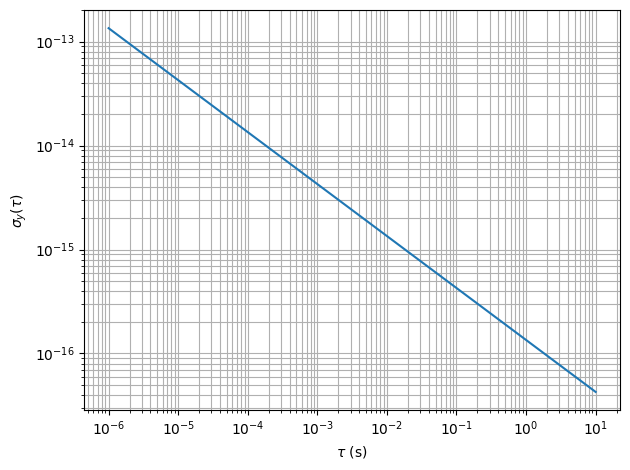

In [ ]:
Delta_f =38.740e6  # in Hz (example value from fitted Lorentzian widths)
f0=f_D12 # in Hz
T_m = 1/(2*np.pi*Delta_f / 2) # in seconds
# T_m = 0.5 / (Gamma_D2 / 2 + Gamma_tr_D2)
L_cell = 0.075   # meters (75 mm)
number = N * np.pi * (D_D2/2)**2 * L_cell   # number of atoms in interaction volume
print("center frequency f0 (THz):", f0/1e12)
print("linewidth Delta_f (MHz):", (Gamma_D2 / 2 + Gamma_tr_D2) / 1e6)
print("interaction time T_m (ns):", T_m * 1e9)
print("number of atoms in interaction volume:", number)

def sigma_y(tau):
    return (1/(2*np.pi*f0)) * np.sqrt(1/(2*number*T_m*tau))

# sigma_y against tau graph in us
# =======================
# Tau range (seconds)
# =======================
tau = np.logspace(-6, 1, 200)  # 1 us to 10 s

# =======================
# Plot
# =======================
plt.figure()
plt.loglog(tau, sigma_y(tau))
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

center frequency f0 (THz): 500.0
linewidth Delta_f (MHz): 3.2147325621730696
interaction time T_m (ns): 0.15915494309189535
number of atoms in interaction volume: 596348822.100152


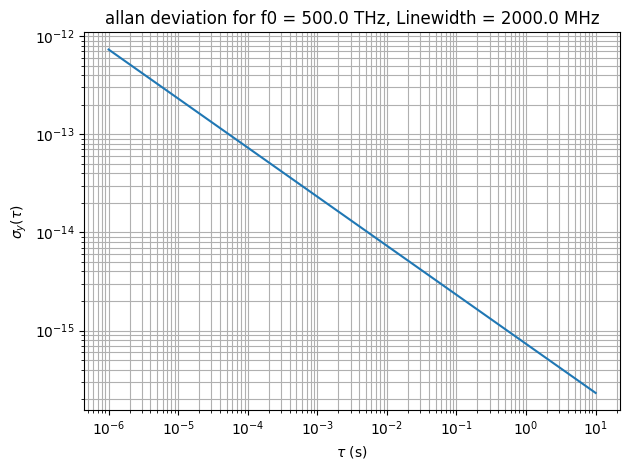

In [40]:
# custom
CHOSEN_F0 = 3
CHOSEN_DELTA_F = 6
f0_array = [193e12, 300e12, 400e12, 500e12]  # Hz
Delta_f_array = [300e3, 1e6, 30e6, 100e6, 300e6, 1e9, 2e9]  # Hz

f0 = f0_array[CHOSEN_F0]  # in Hz
Delta_f = Delta_f_array[CHOSEN_DELTA_F]  # in Hz (example value from fitted Lorentzian widths)

# Delta_f =38.740e6  # in Hz (example value from fitted Lorentzian widths)
# f0=f_D12 # in Hz
T_m = 1/(2*np.pi*Delta_f / 2) # in seconds
# T_m = 0.5 / (Gamma_D2 / 2 + Gamma_tr_D2)
L_cell = 0.075   # meters (75 mm)
number = N * np.pi * (D_D2/2)**2 * L_cell   # number of atoms in interaction volume
print("center frequency f0 (THz):", f0/1e12)
print("linewidth Delta_f (MHz):", (Gamma_D2 / 2 + Gamma_tr_D2) / 1e6)
print("interaction time T_m (ns):", T_m * 1e9)
print("number of atoms in interaction volume:", number)

def sigma_y(tau):
    return (1/(2*np.pi*f0)) * np.sqrt(1/(2*number*T_m*tau))

# sigma_y against tau graph in us
# =======================
# Tau range (seconds)
# =======================
tau = np.logspace(-6, 1, 200)  # 1 us to 10 s

# =======================
# Plot
# =======================
plt.figure()
plt.loglog(tau, sigma_y(tau))
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.grid(True, which='both')
plt.title(f'allan deviation for f0 = {f0/1e12} THz, Linewidth = {Delta_f/1e6} MHz')
plt.tight_layout()
plt.show()

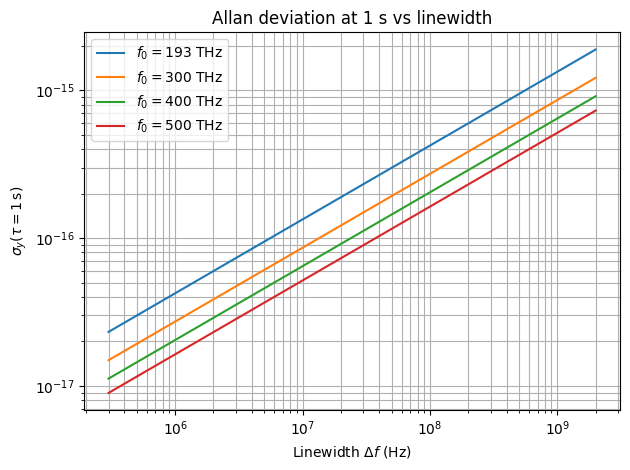

In [41]:
# custom: allan vs linewidth at fixed tau = 1s
tau_fixed = 1.0  # 1 second

# =======================
# Storage
# =======================
allan_vs_linewidth = []

# =======================
# Loop over f0
# =======================
for f0 in f0_array:

    sigma_y_1s = []

    for Delta_f in Delta_f_array:

        # Interaction time (your definition)
        T_m = 1 / (2 * np.pi * Delta_f / 2)

        # Number of atoms
        number = N * np.pi * (D_D2 / 2)**2 * L_cell

        # Allan deviation at tau = 1 s
        sigma = (1 / (2 * np.pi * f0)) * np.sqrt(
            1 / (2 * number * T_m * tau_fixed)
        )

        sigma_y_1s.append(sigma)

    allan_vs_linewidth.append(sigma_y_1s)

# =======================
# Plot
# =======================
plt.figure()

for i, f0 in enumerate(f0_array):
    plt.loglog(
        Delta_f_array,
        allan_vs_linewidth[i],
        label=fr'$f_0 = {f0/1e12:.0f}\ \mathrm{{THz}}$'
    )

plt.xlabel(r'Linewidth $\Delta f$ (Hz)')
plt.ylabel(r'$\sigma_y(\tau = 1\,\mathrm{s})$')
plt.title('Allan deviation at 1 s vs linewidth')
plt.legend()
plt.grid(True, which='both')
plt.tight_layout()
plt.show()
